# <font color='red'>Курсовая работа: Голосование за новые правые партии на выборах в Европарламент 2009-2024 годы </font>

## Электоральные данные
#### Датасет df3_final_1.xlsx

### Описание данных:
Датасет содержит в себе **результаты выборов в Европарламент для всех стран членов союза с 2009 года по 2024 год** (4 электоральных цикла: 2009, 2014, 2019, 2024 годы). 

Также данные содержат **информацию по национальным выборам в законодательные органы для всех стран**: брались выборы до и после выборов в ЕП. Таким образом, **самые ранние** национальные выборы относятся к **2004 году (Люксембург)**, а **самые поздние к 2025 году (ФРГ)**.

Каждая строка -- это результаты конкретной партии на конкретных выборах. **Всего в датасете 1649 наблюдений**.

**Источники данных**: для выборов в ЕП - результаты партий и фракционная принадлежность по сайту ЕП (https://elections.europa.eu/en); результаты национальных выборов собирались по англоязычной википедии со сслыками на национальные ЦИК.

### Описание переменных:
* **type_election**: National - выборы в национальный парламент; EU - выборы в Европарламент 
* **country**: страна проведения выборов (всего 27 стран-членов ЕС)
* **date**: дата проведения выборов
* **turnout**: явка на выборах в %
* **party**: название партии
* **result**: резульат партии в %
* **fraction_EP**: фракция в ЕП, к которой присоединилась партия (только для строк с type_election EU)
* **ideology**: идеология партии: по Chapel Hill Expert Survey.  
* **ruling_party**: роль партии после национальных выборов ( для строк type_election National): 1 - правящая партия единолично либо в коалиции имеет пост главы правительства; 2 - младший партнер в коалиции; 0 - не имеет постов в правительстве
* **notes**: заметки и дополнения по странным случаям в данных


## Опросные данные по Евробарометру
#### Датасет df_eb.xlsx

### Описание данных:
Датасет содержит ответы репондентов стран ЕС по ряду вопросов. Данные взяты из "стандартного евробарометра" -- опроса общественного мнения, которое проводится два раза в год во всех странах ЕС. 

Данные необходимы для зависимых переменных и контрольных переменных -- для тестирования связи евроскептицизма и антидемократических настроений как предикторов голосования за правые партии.

Датасет содержит **данные для 27 стран за 2009, 2014, 2019 и 2024 годы**. Опросы проводились либо за месяц до выборов в ЕП, либо в месяц выборов. Всего **108 наблюдений**.

### Описание переменных:
* **year** год проведения опроса
* **country** страна
* **national_economy_good** положительная оценка состояния национальной экономики (в % от всех респонентов)
* **national_economy_bad** отрицательная оценка состояния национальной экономики (в % от всех респонентов)
* **european_economy_good** положительная оценка состояния экономики ЕС (в % от всех респонентов)
* **european_economy_bad** отрицательная оценка состояния экономики ЕС (в % от всех респонентов)
* **household_good** положительная оценка благосостояния семьи (в % от всех респонентов)
* **household_bad** отрицательная оценка благосостояния семьи (в % от всех респонентов)
* **trust_eu_yes** доверие к институтам ЕС (в % от всех респонентов)
* **trust_eu_no** недоверие к институтам ЕС (в % от всех респонентов)
* **trust_parties_yes** доверие к национальным партиям (в % от всех респонентов)
* **trust_parties_no** недоверие к национальным партиям (в % от всех респонентов)
* **trust_parliment_yes** доверие к национальному парламенту (в % от всех респонентов)
* **trust_parliment_no** недоверие к национальному парламенту (в % от всех респонентов)
* **immigration_out_eu_yes** положительное отношение к иммигрантам не из стран ЕС (в % от всех респонентов)
* **immigration_out_eu_no** отрицательное отношение к иммигрантам не из стран ЕС (в % от всех респонентов)

### Обозначения в файле:

* <font color='red'>Красным обозначены отдельные стадии работы с данными (предобратботка, визуализация, построение моделей и тд)</font>
* <font color='blue'>Синим обозначены блоки внутри стадий (например, выборы в ЕП)</font>
* <font color='green'>Зеленым обозначены темы по отдельным вопросам</font>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.colors import LinearSegmentedColormap
from sklearn.linear_model import LinearRegression
from datetime import datetime
from IPython.display import display
import scipy.stats as stats
from scipy.stats import spearmanr
from linearmodels import PanelOLS
from linearmodels import RandomEffects
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.formula.api as statf
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from linearmodels.panel import compare
from linearmodels.panel.results import compare as compare_results
from statsmodels.stats.diagnostic import acorr_breusch_godfrey
import statsmodels.stats.diagnostic as dg
from scipy.stats import chi2
from statsmodels.stats.diagnostic import het_white
from statsmodels.stats.contrast import ContrastResults
# !pip install stargazer
from stargazer.stargazer import Stargazer
# !pip install imgkit
import imgkit
# !pip install dataframe_image
import dataframe_image as dfi
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# <font color='red'>1.Визуализация данных. Разведочный анализ. Электоральные данные</font>

In [2]:
df = pd.read_excel("df3_final_1.xlsx")

### <font color='green'>Список новых правых партий в датасете</font>

**Для начала выведем список всех "новых правых" партий по странам в нашем датасете**

In [3]:
far_right_parties = df[df['ideology'] == 'Far-right']
grouped = far_right_parties.groupby('country')['party'].unique()
for country, parties in grouped.items():
    print(f"\033[1m{country}\033[0m: {', '.join(parties)}")

Austria: Alliance For The Future Of Austria, Freedom Party Of Austria, Democratic – Neutral – Authentic
Belgium: Vlaams Belang
Bulgaria: Attack, Bulgaria Uncensored, Bulgaria Without Censorship, Patriotic Front, United Patriots, Volya, There Is Such A People, Revival, Greatness, Morale, Unity, Honour
Croatia: Homeland Movement
Cyprus: European Party, Solidarity Movement, ELAM, National People'S Front, National Popular Front
Czechia: Dawn Of Direct Democracy, Freedom And Direct Democracy, Přísaha And Motorists
Denmark: Danish People'S Party, New Right, Denmark Democrats
Estonia: Estonian Independence Party, Conservative People'S Party Of Estonia
Finland: Finns Party
France: National Front, Reconquête, Union Of The Far-Right
Germany: National Democratic Party, German People's Union, Alternative for Germany, Alternative For Germany
Greece: Popular Orthodox Rally, Independent Greeks, Golden Dawn, Greek Solution, Democratic Patriotic Movement "Niki", Spartans, Voice Of Reason
Hungary: Jobbi

## <font color='blue'>1.1 Выборы в ЕвроПарламент</font>

### <font color='green'>Оценим количественную динамику участия новых правых партий в выборах в ЕП.</font>

C:\Users\Acer\AppData\Local\Temp\ipykernel_18480\2517670270.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  eu_elections['date'] = pd.to_datetime(eu_elections['date']).dt.year


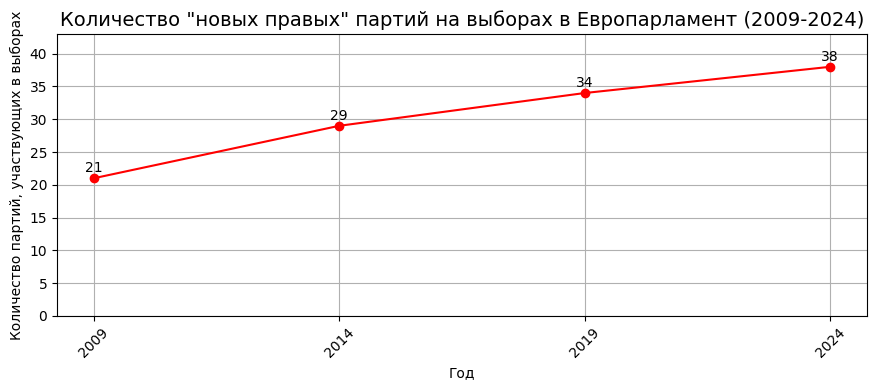

In [4]:
eu_elections = df[df['type_election'] == 'EU']
eu_elections['date'] = pd.to_datetime(eu_elections['date']).dt.year
far_right_parties = eu_elections[eu_elections['ideology'] == 'Far-right']
far_right_counts = far_right_parties.groupby('date').size()

plt.figure(figsize=(9, 4))
plt.plot(far_right_counts.index, far_right_counts.values, marker='o', linestyle='-', color='red')
plt.title('Количество "новых правых" партий на выборах в Европарламент (2009-2024)', fontsize=14)
plt.xlabel('Год', fontsize=10)
plt.ylabel('Количество партий, участвующих в выборах', fontsize=10)
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

plt.xticks(far_right_counts.index, rotation=45)

for i, count in enumerate(far_right_counts.values):
    plt.text(far_right_counts.index[i], count + 0.5, str(count), ha='center', va='bottom')
    
plt.ylim(0, max(far_right_counts.values) + 5)
plt.savefig('количество новых правых партий.png')  # Сохранение графика в формате PNG

plt.show()

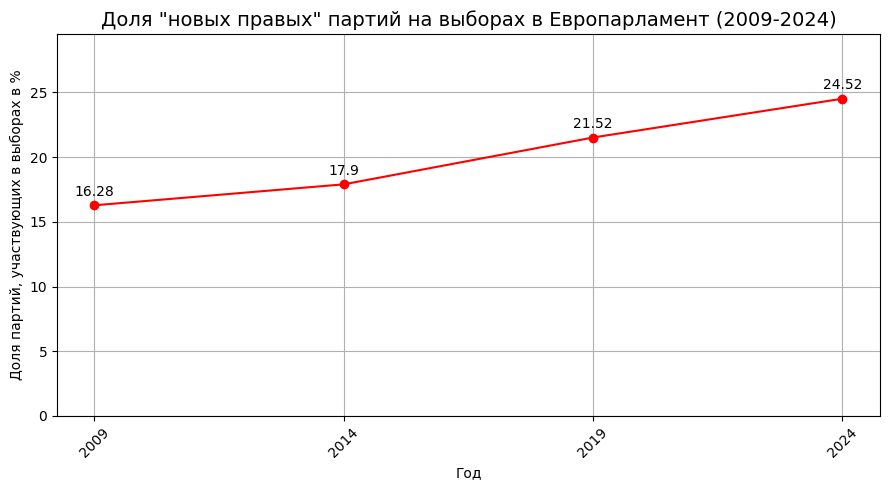

In [5]:
no_far_right_parties = eu_elections[eu_elections['ideology'] != 'Far-right']
no_far_right_parties = no_far_right_parties.groupby('date').size()
share_far_right = far_right_counts / no_far_right_parties * 100
share_far_right = round(share_far_right, 2)

plt.figure(figsize=(9, 5))
plt.plot(share_far_right.index, share_far_right.values, marker='o', linestyle='-', color='red')
plt.title('Доля "новых правых" партий на выборах в Европарламент (2009-2024)', fontsize=14)
plt.xlabel('Год', fontsize=10)
plt.ylabel('Доля партий, участвующих в выборах в %', fontsize=10)
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.xticks(share_far_right.index, rotation=45)
plt.ylim(0, max(share_far_right.values) + 5)

for i, count in enumerate(share_far_right.values):
    plt.text(share_far_right.index[i], count + 0.5, str(count), ha='center', va='bottom')
plt.savefig('доля новый правых.png')  # Сохранение графика в формате PNG


plt.show()

#### ***Выводы***

- Мы наблюдаем, что до 2019 года включиетльно аблосютное число и доля новых правых партий среди всех участвующих в выборах в Европарламент не менялась сильно.
- На выборах 2024 года произошело резкое увеличение количетсва новых правых партий, которые участвуют в выборах: с 23 до 39 или с 14,5% до 25% от общего числа

### <font color='green'>Оценим динамику голосования за новых правых на выборах в ЕП.</font>

C:\Users\Acer\AppData\Local\Temp\ipykernel_18480\1009782776.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  far_right_parties['result'] = pd.to_numeric(far_right_parties['result'], errors='coerce')


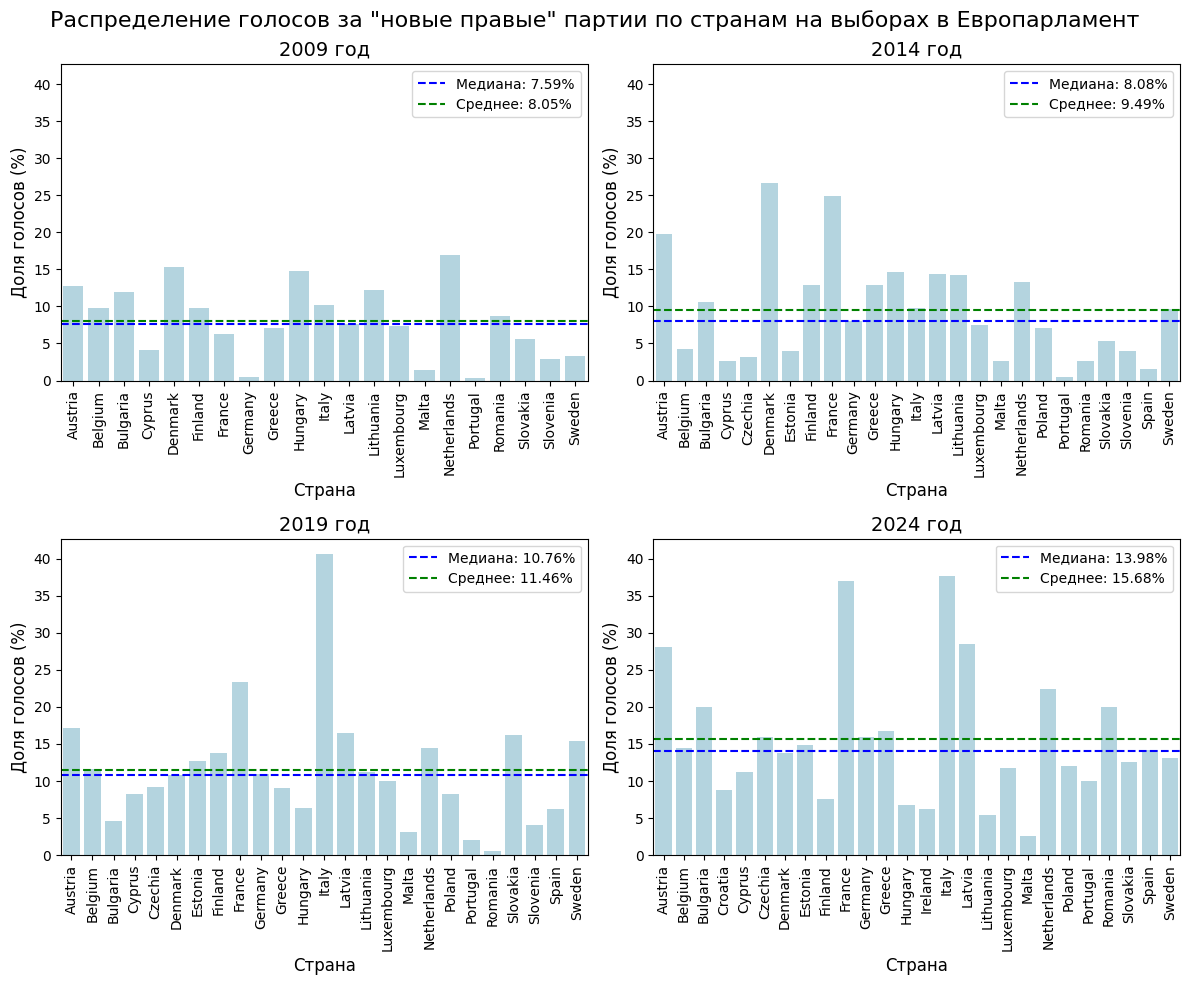

In [6]:
# Убедимся, что столбец result содержит числовые данные
far_right_parties['result'] = pd.to_numeric(far_right_parties['result'], errors='coerce')

# Группировка по странам и годам: суммируем проценты голосов для каждой страны
grouped_data = far_right_parties.groupby(['country', 'date'])['result'].sum().reset_index()

# Создаем сетку графиков (2x2)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Распределение голосов за "новые правые" партии по странам на выборах в Европарламент', fontsize=16)

# Годы выборов
years = [2009, 2014, 2019, 2024]

# Фиксированный цвет для столбцов
bar_color = 'lightblue'

# Найдем максимальное значение для оси Y среди всех данных
y_max = grouped_data['result'].max()

# Построение гистограмм для каждого года
for i, year in enumerate(years):
    ax = axes[i // 2, i % 2]  # Выбор подграфика
    year_data = grouped_data[grouped_data['date'] == year]
    
    # Построение гистограммы с фиксированным цветом
    sns.barplot(x='country', y='result', data=year_data, ax=ax, color=bar_color)
    ax.set_title(f'{year} год', fontsize=14)
    ax.set_xlabel('Страна', fontsize=12)
    ax.set_ylabel('Доля голосов (%)', fontsize=12)
    ax.tick_params(axis='x', rotation=90)  # Поворот подписей стран на 90 градусов

        # Устанавливаем одинаковый диапазон для оси Y на всех графиках
    ax.set_ylim(0, y_max + 2)  # Ось Y начинается с 0 и заканчивается максимальным значением
    
    # Вычисление медианы и среднего
    median = year_data['result'].median()  # Медиана
    mean = year_data['result'].mean()  # Среднее
    
    # Добавление линий для медианы и среднего
    ax.axhline(median, color='blue', linestyle='--', label=f'Медиана: {median:.2f}%')
    ax.axhline(mean, color='green', linestyle='--', label=f'Среднее: {mean:.2f}%')
    
    # Легенда
    ax.legend()

plt.tight_layout()
plt.savefig('Распределение голосов за новые правые партии.png')
plt.show()

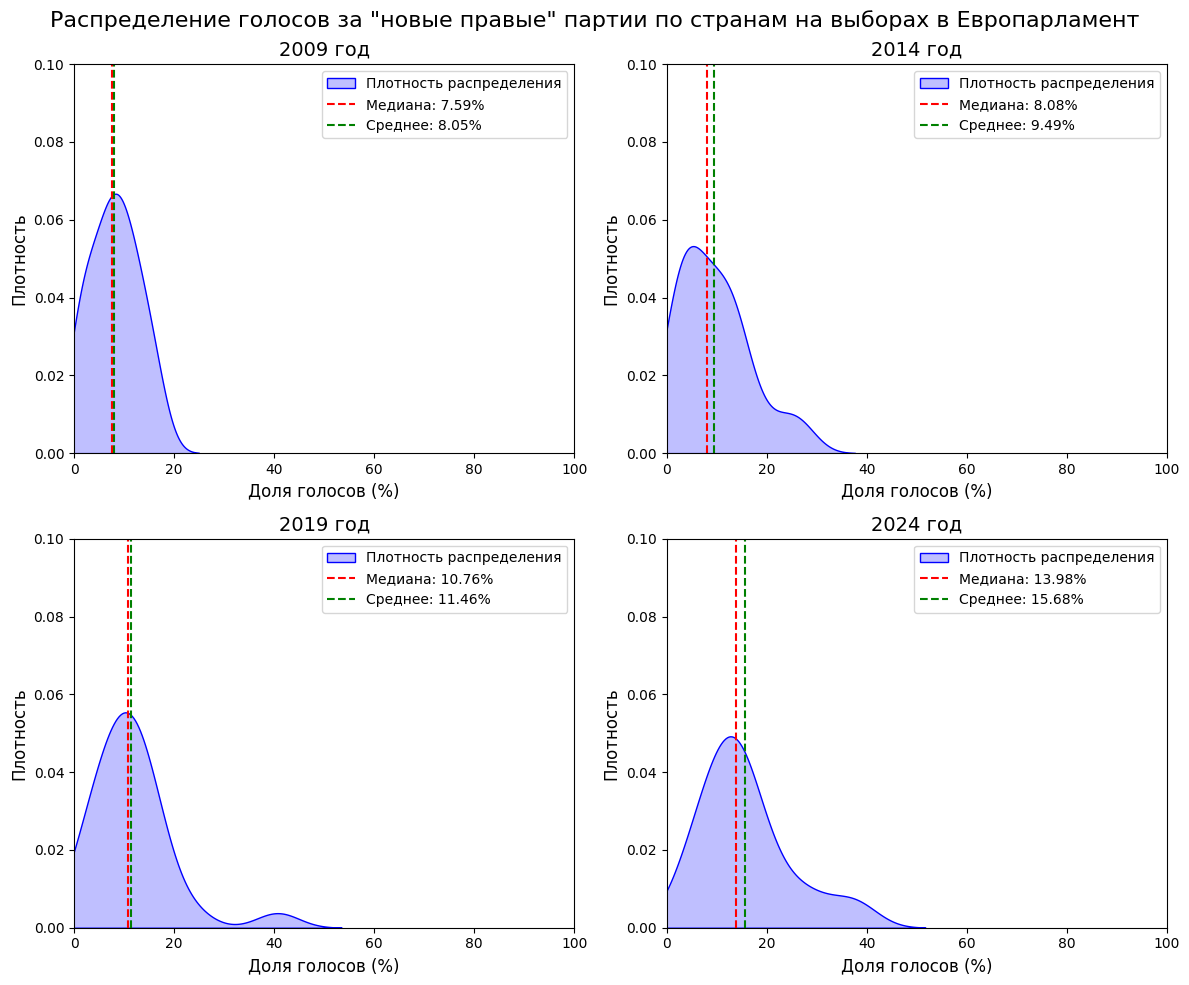

In [7]:
# Группировка по странам и годам: суммируем проценты голосов для каждой страны
grouped_data = far_right_parties.groupby(['country', 'date'])['result'].sum().reset_index()

# Создаем сетку графиков (2x2)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Распределение голосов за "новые правые" партии по странам на выборах в Европарламент', fontsize=16)

# Годы выборов
years = [2009, 2014, 2019, 2024]

# Построение графиков для каждого года
for i, year in enumerate(years):
    ax = axes[i // 2, i % 2]  # Выбор подграфика
    year_data = grouped_data[grouped_data['date'] == year]
    
    # Построение KDE (ядерной оценки плотности)
    sns.kdeplot(year_data['result'], ax=ax, color='blue', fill=True, label='Плотность распределения')
    
    ax.set_title(f'{year} год', fontsize=14)
    ax.set_xlabel('Доля голосов (%)', fontsize=12)
    ax.set_ylabel('Плотность', fontsize=12)
    
    # Устанавливаем пределы осей
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 0.1)
    
    # Добавление вертикальных линий для медианы и среднего
    median = year_data['result'].median()
    mean = year_data['result'].mean()
    
    ax.axvline(median, color='red', linestyle='--', label=f'Медиана: {median:.2f}%')
    ax.axvline(mean, color='green', linestyle='--', label=f'Среднее: {mean:.2f}%')
    
    # Легенда
    ax.legend()

plt.tight_layout()
plt.show()

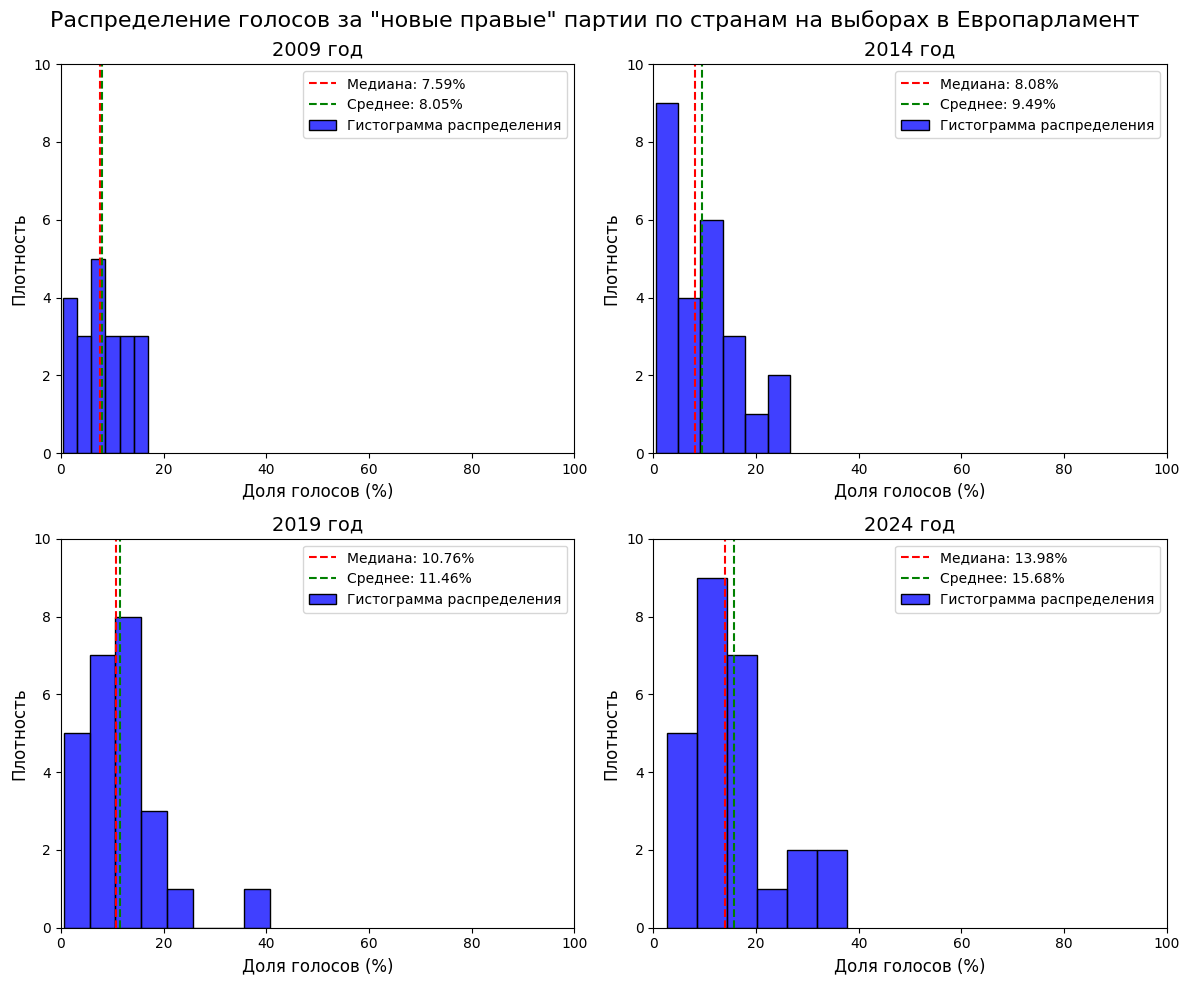

In [8]:
# Группировка по странам и годам: суммируем проценты голосов для каждой страны
grouped_data = far_right_parties.groupby(['country', 'date'])['result'].sum().reset_index()

# Создаем сетку графиков (2x2)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Распределение голосов за "новые правые" партии по странам на выборах в Европарламент', fontsize=16)

# Годы выборов
years = [2009, 2014, 2019, 2024]

# Построение графиков для каждого года
for i, year in enumerate(years):
    ax = axes[i // 2, i % 2]  # Выбор подграфика
    year_data = grouped_data[grouped_data['date'] == year]
    
    # Построение гистограмм
    sns.histplot(year_data['result'], ax=ax, color='blue', fill=True, label='Гистограмма распределения')
    
    ax.set_title(f'{year} год', fontsize=14)
    ax.set_xlabel('Доля голосов (%)', fontsize=12)
    ax.set_ylabel('Плотность', fontsize=12)
    
    # Устанавливаем пределы осей
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 10) 
    
    # Добавление вертикальных линий для медианы и среднего
    median = year_data['result'].median()
    mean = year_data['result'].mean()
    
    ax.axvline(median, color='red', linestyle='--', label=f'Медиана: {median:.2f}%')
    ax.axvline(mean, color='green', linestyle='--', label=f'Среднее: {mean:.2f}%')
    
    # Легенда
    ax.legend()

plt.tight_layout()
plt.show()

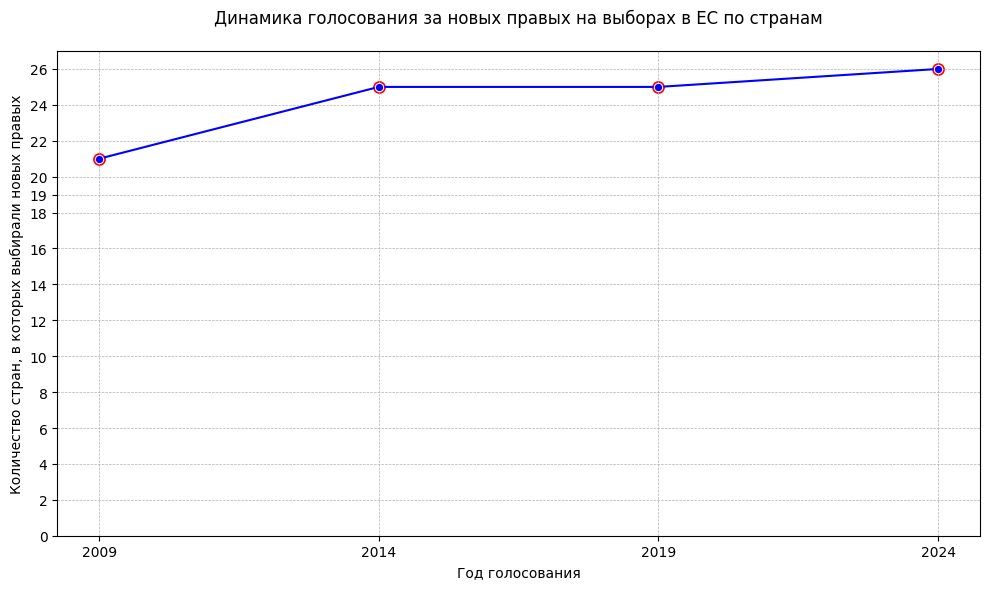

In [9]:
# Группировка по году и подсчет уникальных стран
grouped_data = far_right_parties.groupby('date')['country'].nunique().reset_index()

# Построение графика
plt.figure(figsize=(10, 6))

# Линия с интерполяцией для плавности
sns.lineplot(data=grouped_data, x='date', y='country', marker='o', linestyle='-', color='b')

# Точки только на даты выборов
sns.scatterplot(data=grouped_data, x='date', y='country', color='r', s=100)

# Настройка оси X: только годы голосования
plt.xticks(grouped_data['date'])

# Настройка оси Y: добавляем значения 16, 19, 26 и другие с шагом 2
y_min = 0
y_max = 27  # Максимальное значение оси Y
y_step = 2  # Шаг для значений оси Y
y_values = np.arange(y_min, y_max + 1, y_step)  # Создаем значения с шагом 2
y_values = sorted(list(set(y_values) | {16, 19, 26}))  # Добавляем обязательные значения
plt.yticks(y_values)  # Устанавливаем значения на оси Y
plt.ylim(y_min, y_max)  # Устанавливаем диапазон оси Y

# Настройка сетки: чтобы она пересекала точки по обеим осям
plt.grid(True, which='both', axis='both', linestyle='--', linewidth=0.5)

# Заголовок и подписи осей
plt.title('Динамика голосования за новых правых на выборах в ЕС по странам', pad=20)
plt.xlabel('Год голосования')
plt.ylabel('Количество стран, в которых выбирали новых правых')
plt.tight_layout()
plt.show()

#### ***Выводы***

- Мы видии за 4 электоральных цикла постоянный рост доли голосов, получаемых новыми правыми партиями: среднее значение выросло с 9,8% в 2009 году до 17,4% в 2024 году. Заметим, что медиана выросла не так значительно: с 9,8% до 14,3%.
- Графики распределения подтверждают анализ медианных значений: распределение доли голосов скошено вправо. Это значит, что у нас есть отдельные страны, в которых новые праве получают значительно больше голосов, чем в среднем по всем странам ЕС.
- Графики распределения голосов по отдельным странам также указывают на неоднородность голосования за правых в расзере стран Союза. На выборах 2024 года лишь в нескольких странах новые правые получили больше среднего значения: Австрия, Болгария, Франция, Венгрия, Италия, Литва, Нидерланды, Румыния.
- При этом по графикам мы можем сделать вывод о росте популярности новых правых к 2024 году: так на протяжении 3 электоральных циклов новые правые были представлены 16-19 странах союза, а на выборах 2024 года за эти партии уже голосовали в 26 из 27 стран ЕС.


## <font color='blue'>1.2 Выборы в национальные парламенты</font>

### <font color='green'>Динамика голосования за новых правых по странам и по Европе в целом</font>

**Визуализировать динамику голосования для 27 стран непросто: главная сложность это то, что выборы в национальные легислатуры проводятся в разных странах в разные года. Поэтому сделать единый график для каждого года выборов невозможно. Принято решение построить heat map, где для каждой страны будет показана динамика голосования за новых правых (чем более красный цвет, тем более высокая доля голосов). При этом такой график позволяет сделать визуализацию экономомной и удобной для изучения.**

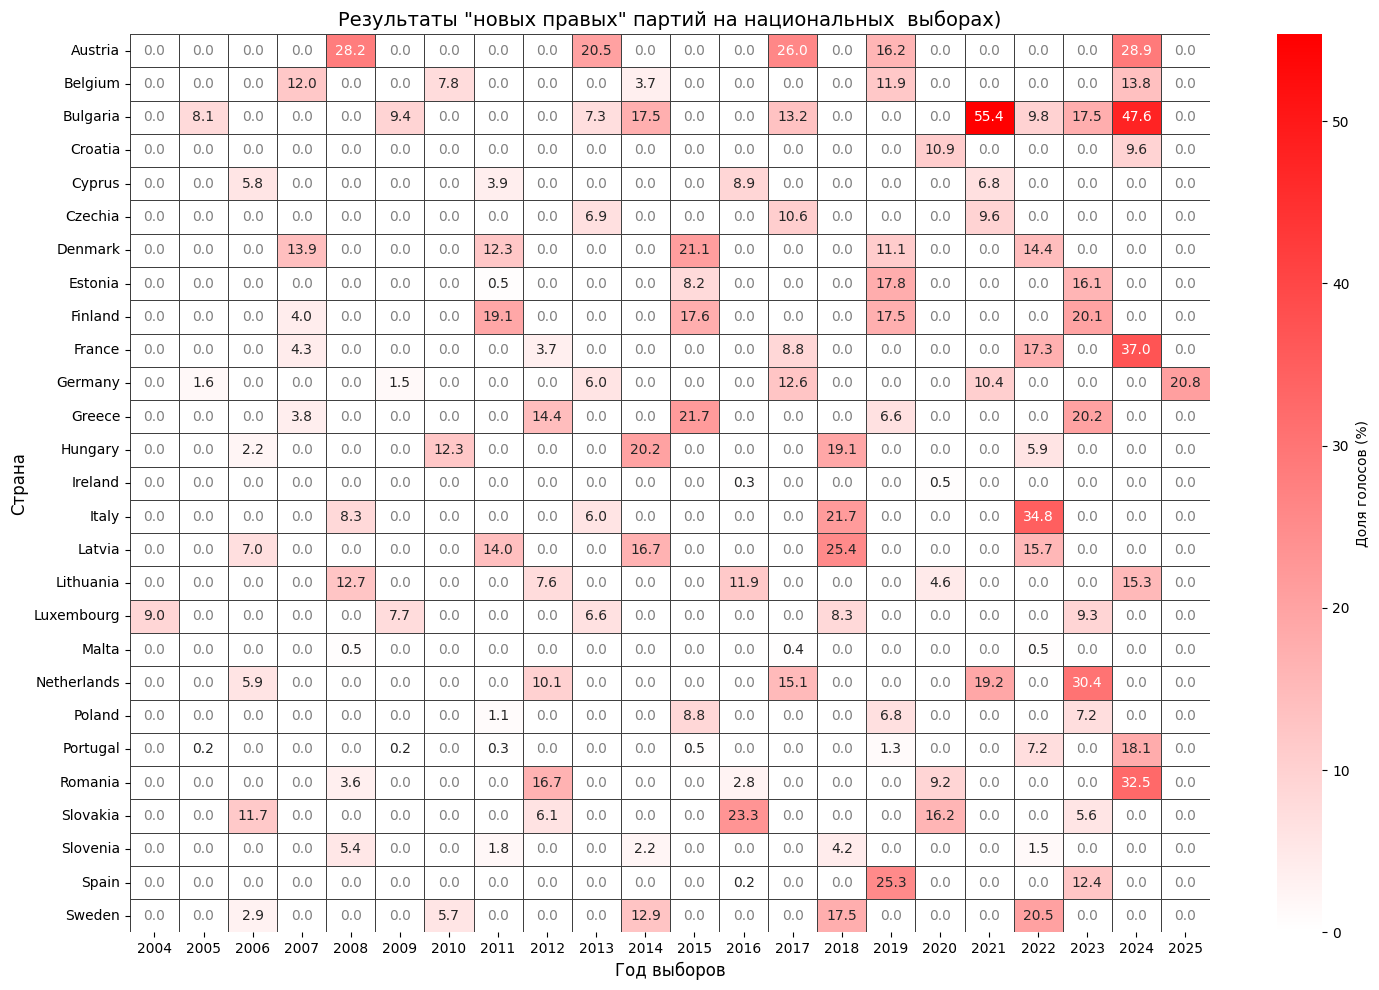

In [10]:
filtered = df[
    (df['type_election'] == 'National') & 
    (df['ideology'] == 'Far-right')
].copy()
# Преобразование даты и очистка
filtered['year'] = pd.to_datetime(filtered['date'], errors='coerce').dt.year
filtered = filtered.dropna(subset=['year', 'result'])

# 1. Создание сводной таблицы
pivot_table = filtered.pivot_table(
    index='country',
    columns='year',
    values='result',
    aggfunc='sum',
    fill_value=0
)

# 2. Кастомная цветовая карта (белый → красный)
colors = ["#ffffff", "#ff0000"]  # Белый → Красный
cmap = LinearSegmentedColormap.from_list("custom_white_red", colors)

# 3. Визуализация с настройками
plt.figure(figsize=(15, 10))
ax = sns.heatmap(
    pivot_table,
    annot=True,
    cmap=cmap,
    fmt='.1f',
    linewidths=0.5,
    linecolor='#404040',
    cbar_kws={'label': 'Доля голосов (%)'},
    vmin=0,
    vmax=pivot_table.max().max()  # Автоматическое определение максимума
)

# 4. Настройка внешнего вида
ax.set_facecolor('#f8f8f8')  # Светло-серый фон вокруг таблицы

# 5. Настройка текста для нулевых значений
for text in ax.texts:
    if text.get_text() == "0.0":
        text.set_color('#808080')  # Серый цвет текста для нулей

plt.title('Результаты "новых правых" партий на национальных  выборах)', fontsize=14)
plt.xlabel('Год выборов', fontsize=12)
plt.ylabel('Страна', fontsize=12)
plt.tight_layout()
plt.savefig('Результаты новых правых партий на национальных выборах.png')
plt.show()

**Примечание:** для Болгарии указана сумма процентов за все выборы, которые проходили в этот год. 

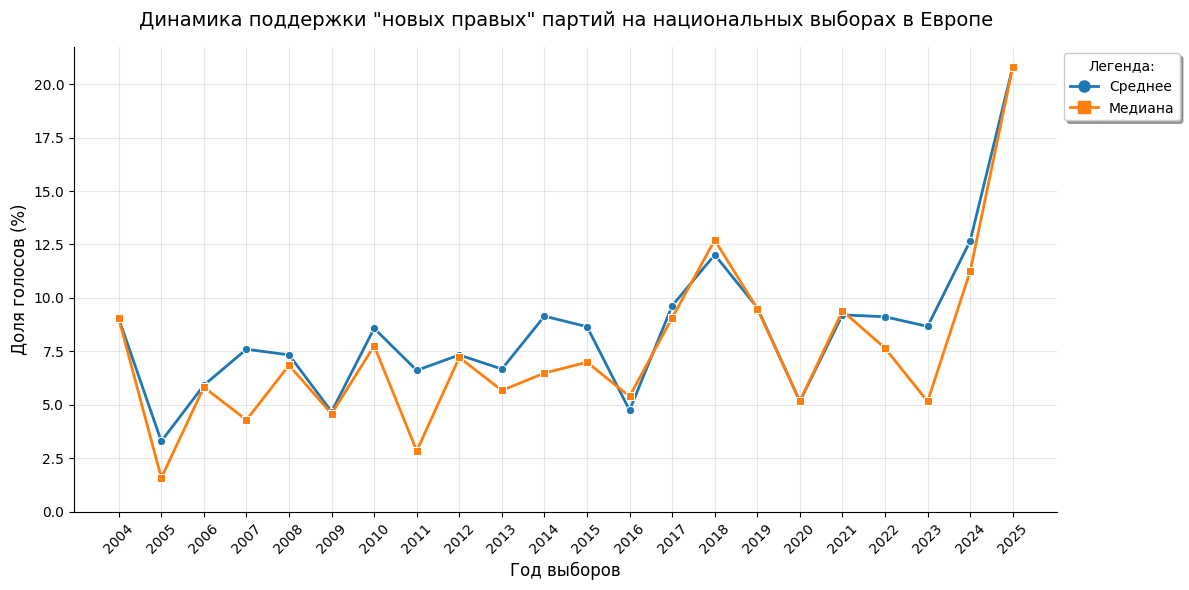

In [11]:
# Фильтрация данных
filtered = df[
    (df['type_election'] == 'National') & 
    (df['ideology'] == 'Far-right')
].copy()

# Преобразование даты и очистка
filtered['year'] = pd.to_datetime(filtered['date'], errors='coerce').dt.year
filtered = filtered.dropna(subset=['year', 'result'])

# Расчет агрегированных показателей
europe_trend = filtered.groupby('year')['result'].agg(['mean', 'median']).reset_index()

# Подготовка данных для визуализации
melted_data = europe_trend.melt(
    id_vars='year', 
    value_vars=['mean', 'median'], 
    var_name='metric', 
    value_name='value'
)

# Создание графики
plt.figure(figsize=(12, 6))
ax = sns.lineplot(
    data=melted_data,
    x='year', 
    y='value', 
    hue='metric',
    style='metric',
    markers={'mean': 'o', 'median': 's'},
    dashes=False,
    linewidth=2,
    palette={'mean': '#1f77b4', 'median': '#ff7f0e'},
    hue_order=['mean', 'median'],
    style_order=['mean', 'median']
)

# Ручное создание элементов легенды
legend_elements = [
    plt.Line2D([0], [0], color='#1f77b4', marker='o', linestyle='-', 
               markersize=8, linewidth=2, label='Среднее'),
    plt.Line2D([0], [0], color='#ff7f0e', marker='s', linestyle='-', 
               markersize=8, linewidth=2, label='Медиана')
]

# Настройка графика
plt.title('Динамика поддержки "новых правых" партий на национальных выборах в Европе', 
          pad=15, fontsize=14)
plt.xlabel('Год выборов', fontsize=12)
plt.ylabel('Доля голосов (%)', fontsize=12)
plt.xticks(europe_trend['year'].unique(), rotation=45)
plt.grid(alpha=0.3)
ax.set_ylim(bottom=0)  

# Установка легенды
ax.legend(
    handles=legend_elements,
    title='Легенда:',
    frameon=True,
    shadow=True,
    loc='upper left',
    bbox_to_anchor=(1, 1)  # Выносит легенду за пределы графика
)

sns.despine()
plt.tight_layout()
plt.savefig('Динамика поддержки новых правых партий.png')
plt.show()

**Примечание:** 2025 год на графике можно считать выбросом. Там учитываются только выборы в ФРГ,поэтому так резко медиана поднимается. За все прошлые годы мы не видим таких резкий взлетов. 

#### ***Выводы***

- На основе визуализации этого блока сложно делать какие-то выводы. Однако она позволяет нам смотреть на динамику голосования за новых правых в отдельных странах.
- При этом по отдельным странам мы можем заметить, что новые правые там также стали получать значительные доли голосов и на национальных выборах в парламенты.
- Что касается средних показателй новых правых на национальных выборах, то за все время наблюдений эти значения колеблются в районе 7,5 - 12,5 %.

### <font color='green'>Динамика участия новых правых в правительственных коалициях</font>

C:\Users\Acer\AppData\Local\Temp\ipykernel_18480\2372615418.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
C:\Users\Acer\AppData\Local\Temp\ipykernel_18480\2372615418.py:20: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  ax = sns.barplot(
C:\Users\Acer\AppData\Local\Temp\ipykernel_18480\2372615418.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


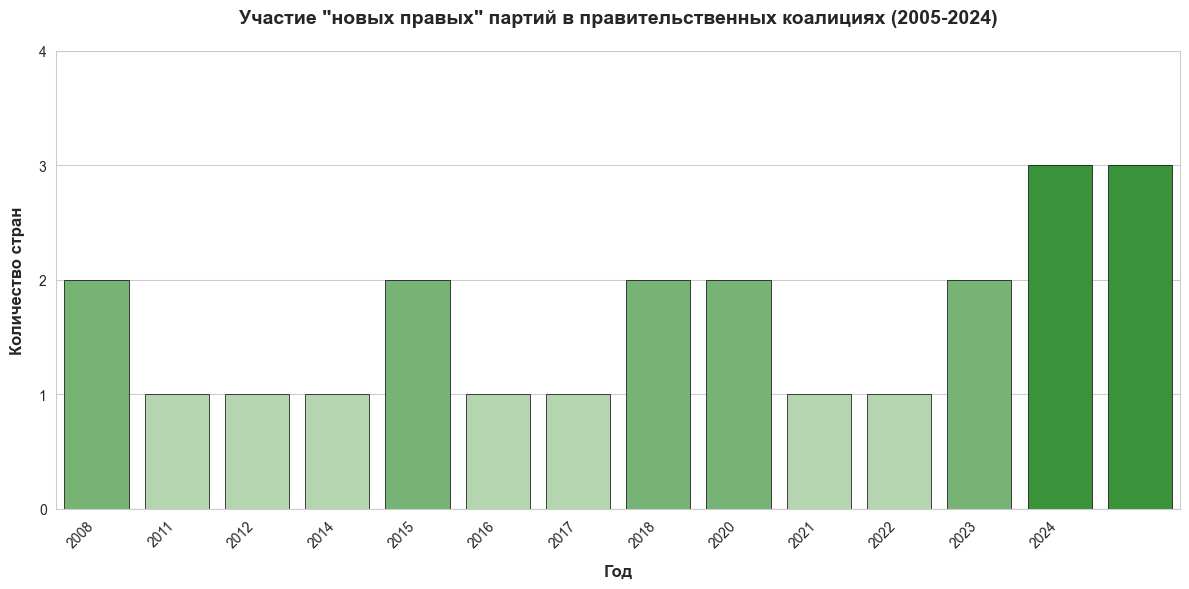

In [12]:
# Фильтрация данных
filtered = df[
    (df['type_election'] == 'National') &
    (df['ideology'] == 'Far-right') &
    (df['ruling_party'].isin([1, 2]))
].copy()

# Извлечение года и группировка
filtered['year'] = pd.to_datetime(filtered['date']).dt.year
countries_count = filtered.groupby('year')['country'].nunique().reset_index()
countries_count.columns = ['Год', 'Количество стран']

# Создание градиентной цветовой карты
colors = ["#f0f9e8", "#2ca02c"]
cmap = LinearSegmentedColormap.from_list("custom_green", colors)

# Построение графика
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
ax = sns.barplot(
    data=countries_count,
    x='Год',
    y='Количество стран',
    palette=cmap(countries_count['Количество стран'] / countries_count['Количество стран'].max()),
    edgecolor='black',
    linewidth=0.5
)

# Настройка осей и аннотаций
plt.ylim(0, countries_count['Количество стран'].max() + 1)
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.xlabel('Год', fontsize=12, labelpad=10, fontweight='bold')
plt.ylabel('Количество стран', fontsize=12, labelpad=10, fontweight='bold')
plt.title('Участие "новых правых" партий в правительственных коалициях (2005-2024)', 
          fontsize=14, pad=20, fontweight='bold')


# Формати#рование оси X
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(1)) 

plt.tight_layout()
plt.show()

**Таблица:** тут показано участие новых правых в правительственных коалициях в разрере стран

In [13]:
country_year_table = filtered.pivot_table(
    index='country',
    columns='year',
    aggfunc='size',
    fill_value=0
)
print("Участие новых правых в правительстве по странам и годам:")
print(country_year_table)

Участие новых правых в правительстве по странам и годам:
year         2006  2008  2011  2012  2014  2015  2016  2017  2018  2020  2021  \
country                                                                         
Austria         0     0     0     0     0     0     0     1     0     0     0   
Bulgaria        0     0     0     0     1     0     0     1     0     0     1   
Croatia         0     0     0     0     0     0     0     0     0     0     0   
Finland         0     0     0     0     0     0     0     0     0     0     0   
Greece          0     0     0     0     0     2     0     0     0     0     0   
Italy           0     1     0     0     0     0     0     0     1     0     0   
Latvia          1     0     1     0     1     0     0     0     1     0     0   
Lithuania       0     0     0     1     0     0     0     0     0     0     0   
Netherlands     0     0     0     0     0     0     0     0     0     0     0   
Slovakia        1     0     0     0     0     0     

## <font color='blue'>1.3 Выборы 1 и 2 порядка: сравнение выступлений новых правых</font>

**Описание таблицы:**

Показывает динамику голосования за новых правых по странам для двух типов выборов:
- eu_result_год показывает сколько получили новые правые партии в стране на выборах в ЕП
- before_год показывает результут новых правых на национальных выборах до выборов в ЕП
- after_год показывает результут новых правых на национальных выборах после выборов в ЕП


**Примечания и концептуальные сложности:**
- пока не придумал как лучше делатьв  ситуации, когда обо типа выборов проходят в одни день. Например, в Бельгии такая ситуация.
- нужно держать в голове, что, например, в группу "выборо до выборов в ЕП" попадают выборы в национальное собрание, которые в одной стране прошли за 1 год до выбров в ЕП и выборы в другой стране, где выборы в национальное собрание прошли за 3-4 года до выборов в ЕП. Очевидно, что голосование на таких выборах отличается в силу большого временного разрыва. 

In [14]:
df['date'] = pd.to_datetime(df['date'])

# Подготовка данных
eu_elections = df[df['type_election'] == 'EU']
national_elections = df[df['type_election'] == 'National']

results = []

for country in eu_elections['country'].unique():
    one_line = {'country': country}
    country_data_eu = eu_elections[eu_elections['country']==country]
    country_data_nat = national_elections[national_elections['country']==country]
    eu_dates = sorted(list(country_data_eu['date'].unique()))
    # print(country, eu_dates)
    for i, dt in enumerate(eu_dates):
        # if country_data_eu[(country_data_eu['ideology'] == 'Far-right')&(country_data_eu['date']==dt)].shape[0] > 0:
        eu_result = country_data_eu[(country_data_eu['ideology'] == 'Far-right')&(country_data_eu['date']==dt)]['result'].sum()
        if eu_result == 0:
            eu_result = np.nan
        if i > 0:
            before_eu_data = country_data_nat[(country_data_nat['date']<=dt)&(country_data_nat['date']>eu_dates[i-1])]
        else:
            before_eu_data = country_data_nat[(country_data_nat['date']<=dt)]
        before_eu_date_max = before_eu_data['date'].max()
        before = before_eu_data[(before_eu_data['ideology'] == 'Far-right')&(before_eu_data['date'] == before_eu_date_max)]
        if before.shape[0]>0:
            
            one_line[f'before_{dt.year}']=before['result'].sum()
        else:
            one_line[f'before_{dt.year}']=np.nan

        one_line[f"eu_result_{dt.year}"] = eu_result

        if i < len(eu_dates)-1:
            after_eu_data = country_data_nat[(country_data_nat['date']>=dt)&(country_data_nat['date']<eu_dates[i+1])]
        else:
            after_eu_data = country_data_nat[country_data_nat['date']>=dt]
        after_eu_date_min = after_eu_data['date'].min()
        after = after_eu_data[(after_eu_data['ideology'] == 'Far-right')&(after_eu_data['date'] == after_eu_date_min)]
        if after.shape[0]>0:
            one_line[f'after_{dt.year}']=after['result'].sum()
        else:
            one_line[f'after_{dt.year}']=np.nan
    results.append(one_line)
    
final_df = pd.DataFrame.from_dict(results).set_index('country')
final_df

,before_2009,eu_result_2009,after_2009,before_2014,eu_result_2014,after_2014,before_2019,eu_result_2019,after_2019,before_2024,eu_result_2024,after_2024
country,,,,,,,,,,,,
Austria,28.20,12.71,20.51,20.51,19.72,25.97,25.97,17.20,16.17,16.17,28.08,28.85
Belgium,11.99,9.85,7.76,3.67,4.26,3.67,11.95,11.68,11.95,13.77,14.50,13.77
Bulgaria,8.14,11.96,9.36,7.30,10.66,17.49,13.22,4.55,17.40,23.69,20.02,23.69
Latvia,6.99,7.59,14.01,14.01,14.36,16.72,25.41,16.49,15.71,15.71,28.55,NaN
Croatia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.89,9.56,8.84,NaN
Denmark,13.86,15.28,12.32,12.32,26.61,21.08,21.08,10.76,11.10,14.43,13.76,NaN
Cyprus,5.75,4.12,3.88,3.88,2.69,8.95,8.95,8.25,6.78,6.78,11.19,NaN
Czechia,NaN,NaN,NaN,6.89,3.12,10.64,10.64,9.14,9.56,9.56,15.99,NaN
Estonia,NaN,NaN,0.45,0.45,4.03,8.15,17.76,12.73,16.05,16.05,14.86,NaN


In [15]:
# final_df_before  = final_df

# final_df_before['diff_before_2009'] = final_df_before.eu_result_2009 - final_df_before.before_2009
# final_df_before['diff_before_2014'] = final_df_before.eu_result_2014 - final_df_before.before_2014
# final_df_before['diff_before_2019'] = final_df_before.eu_result_2019 - final_df_before.before_2019
# final_df_before['diff_before_2024'] = final_df_before.eu_result_2024 - final_df_before.before_2024

# d2009 = final_df_before.pop('diff_before_2009')
# d2014 = final_df_before.pop('diff_before_2014')
# d2019 = final_df_before.pop('diff_before_2019')
# d2024 = final_df_before.pop('diff_before_2024')

# final_df_before.insert(2, 'diff_before_2009', d2009)
# final_df_before.insert(4, 'diff_before_2014', d2014)
# final_df_before.insert(6, 'diff_before_2019', d2019)
# final_df_before.insert(8, 'diff_before_2024', d2024)

# final_df_before.pop('after_2009')
# final_df_before.pop('after_2014')
# final_df_before.pop('after_2019')
# final_df_before.pop('after_2024')

# final_df_before

**ВОПРОС ПРО ГРЕЦИЮ И ЕЕ НАН**

### <font color='green'>Тесты на сравнение результатов на разных типах выборов</font>

Так как наши данные не независимые (партии участвуют и в нациальных выборах и в выборах в ЕП), а также наша выборка не очень большая, то подойдут непараметрические тесты на сравнение средних. **Наша цель** -- первично прикинуть, есть ли статистическая разница в результатах правых партий на национальных выборах и их же резульататх на выборах в ЕП. 

In [16]:
def calc_corr(year):
    elec = final_df[[f'before_{year}', f'eu_result_{year}']]
    elec = elec.dropna()
    print("Количество наблюдений: ",elec.shape[0])
    print("Тест Вилкоксона: ",stats.wilcoxon(elec[f'before_{year}'], elec[f'eu_result_{year}']))
    coef, p_value = spearmanr(elec[f'before_{year}'], elec[f'eu_result_{year}'])
    print(f"Корреляция Спирмена: coef: {round(coef, 4)}, p-value: {round(p_value,4)} for year: {year}")
    print()

In [17]:
years = [2009, 2014, 2019, 2024]
for y in years:
    calc_corr(y)

Количество наблюдений:  21
Тест Вилкоксона:  WilcoxonResult(statistic=86.0, pvalue=0.32045745849609375)
Корреляция Спирмена: coef: 0.6195, p-value: 0.0027 for year: 2009

Количество наблюдений:  23
Тест Вилкоксона:  WilcoxonResult(statistic=96.0, pvalue=0.21117830276489258)
Корреляция Спирмена: coef: 0.5683, p-value: 0.0047 for year: 2014

Количество наблюдений:  24
Тест Вилкоксона:  WilcoxonResult(statistic=78.0, pvalue=0.03948163986206055)
Корреляция Спирмена: coef: 0.6617, p-value: 0.0004 for year: 2019

Количество наблюдений:  26
Тест Вилкоксона:  WilcoxonResult(statistic=104.0, pvalue=0.07092106342315674)
Корреляция Спирмена: coef: 0.635, p-value: 0.0005 for year: 2024



**Вывод** 
По тесту Вилкоксона мы не видим стат. значимой разницой между результатами правых на национальных выборах и выборах в ЕП
При этом корреляция Спирмена значима длявсех 4 периодов, оценка положительная: с повышением популярности на нац.выборах растет поддержка правых и на следующих выборах в ЕП.

# <font color='red'>2.Визуализация данных. Разведочный анализ. Данные Евробарометр</font>

## <font color='blue'>Подготовка</font>

In [18]:
# df_eb_09 = pd.read_excel('eurobar_df_2009.xlsx')
# df_eb_14 = pd.read_excel('eurobar_df_2014.xlsx')
# df_eb_19 = pd.read_excel('eurobar_df_2019.xlsx')
# df_eb_24 = pd.read_excel('eurobar_df_2024.xlsx')
# df_eb = pd.concat([df_eb_09, df_eb_14,df_eb_19,df_eb_24], axis=0)
df_eb = pd.read_csv('df_eb.csv')
df_eb.head()

,year,country,NATIONAL_economy_good,NATIONAL_economy_bad,European_economy_good,European_economy_bad,household_good,household_bad,trust_eu_yes,trust_eu_no,trust_parties_yes,trust_parties_no,trust_parliment_yes,trust_parliment_no,immigration_out_eu_yes,immigration_out_eu_no,name
0,2009,BE,0.22,0.77,0.26,0.72,0.79,0.20,0.59,0.37,0.28,0.70,0.41,0.56,NaN,NaN,Belgium
1,2009,BG,0.10,0.87,0.39,0.42,0.32,0.65,0.63,0.23,0.13,0.82,0.10,0.85,NaN,NaN,Bulgaria
2,2009,CZ,0.19,0.81,0.26,0.71,0.64,0.35,0.55,0.40,0.15,0.83,0.20,0.78,NaN,NaN,Czechia
3,2009,DK,0.69,0.30,0.47,0.48,0.89,0.10,0.58,0.37,0.58,0.38,0.75,0.22,NaN,NaN,Denmark
4,2009,DE,0.23,0.75,0.20,0.76,0.73,0.25,0.46,0.44,0.24,0.71,0.46,0.47,NaN,NaN,Germany


In [19]:
country_map = {'AT': 'Austria', 'BE': 'Belgium', 'BG': 'Bulgaria', 'CY':'Cyprus', 'CZ':'Czechia', 'DK': 'Denmark',
'EE': 'Estonia', 'FI': 'Finland', 'FR': 'France', 'DE': 'Germany', 'EL': 'Greece', 'HU':'Hungary', 'IE': 'Ireland', 'IT':'Italy',
'LV': 'Latvia', 'LT':'Lithuania', 'LU':'Luxembourg','MT':'Malta', 'NL':'Netherlands', 'PL':'Poland', 'PT':'Portugal', 'RO':'Romania',
'SK': 'Slovakia', 'SI':'Slovenia', 'ES':'Spain', 'SE':'Sweden', 'HR':'Croatia'}

In [20]:
df_eb['name'] = df_eb['country'].map(country_map)
df_eb = df_eb[df_eb['name'].notna()]

In [21]:
df_eb = df_eb.rename(columns={'NATIONAL_economy_good': 'national_economy_good', 'NATIONAL_economy_bad':'national_economy_bad',
                             'European_economy_good': 'european_economy_good', 'European_economy_bad':'european_economy_bad'})
df_eb.head()

,year,country,national_economy_good,national_economy_bad,european_economy_good,european_economy_bad,household_good,household_bad,trust_eu_yes,trust_eu_no,trust_parties_yes,trust_parties_no,trust_parliment_yes,trust_parliment_no,immigration_out_eu_yes,immigration_out_eu_no,name
0,2009,BE,0.22,0.77,0.26,0.72,0.79,0.20,0.59,0.37,0.28,0.70,0.41,0.56,NaN,NaN,Belgium
1,2009,BG,0.10,0.87,0.39,0.42,0.32,0.65,0.63,0.23,0.13,0.82,0.10,0.85,NaN,NaN,Bulgaria
2,2009,CZ,0.19,0.81,0.26,0.71,0.64,0.35,0.55,0.40,0.15,0.83,0.20,0.78,NaN,NaN,Czechia
3,2009,DK,0.69,0.30,0.47,0.48,0.89,0.10,0.58,0.37,0.58,0.38,0.75,0.22,NaN,NaN,Denmark
4,2009,DE,0.23,0.75,0.20,0.76,0.73,0.25,0.46,0.44,0.24,0.71,0.46,0.47,NaN,NaN,Germany


## <font color='blue'>Визуализация</font>

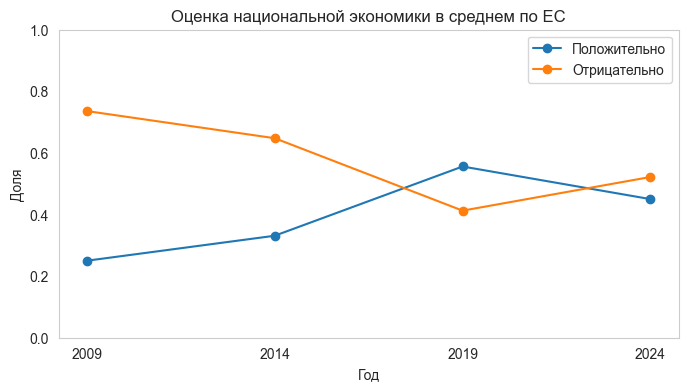

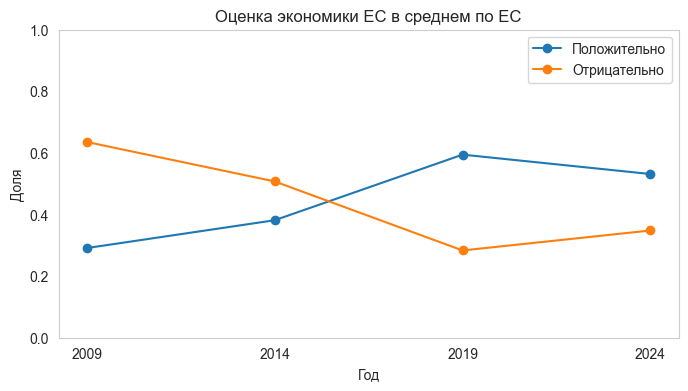

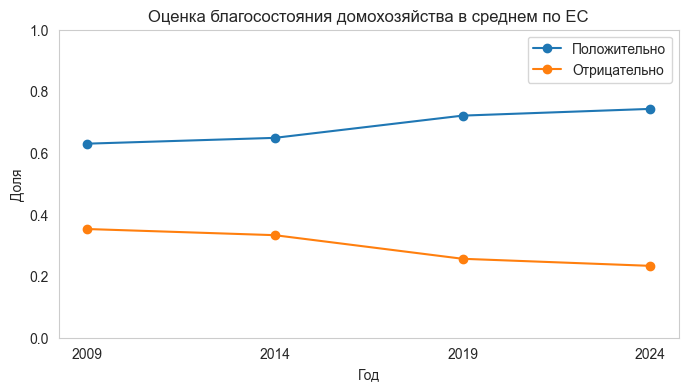

In [22]:
def plot_economy_trend(good_column, bad_column, title):
    # Группировка данных по годам и вычисление среднего значения
    grouped = df_eb.groupby('year')[[good_column, bad_column]].mean()
    
    # Создание графика
    plt.figure(figsize=(8, 4))
    plt.plot(grouped.index, grouped[good_column], label='Положительно', marker='o')
    plt.plot(grouped.index, grouped[bad_column], label='Отрицательно', marker='o')
    
    plt.title(title)
    plt.xlabel('Год')
    plt.ylabel('Доля')
    plt.legend()
    plt.grid()
    plt.xticks(grouped.index)
    plt.ylim(0, 1)  # Ограничиваем ось Y от 0 до 1
    plt.show()

# экономика
plot_economy_trend('national_economy_good', 'national_economy_bad', 'Оценка национальной экономики в среднем по ЕС')
plot_economy_trend('european_economy_good', 'european_economy_bad', 'Оценка экономики ЕС в среднем по ЕС')
plot_economy_trend('household_good', 'household_bad', 'Оценка благосостояния домохозяйства в среднем по ЕС')


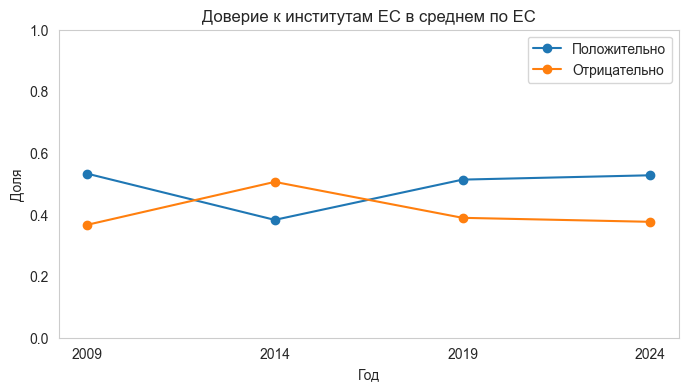

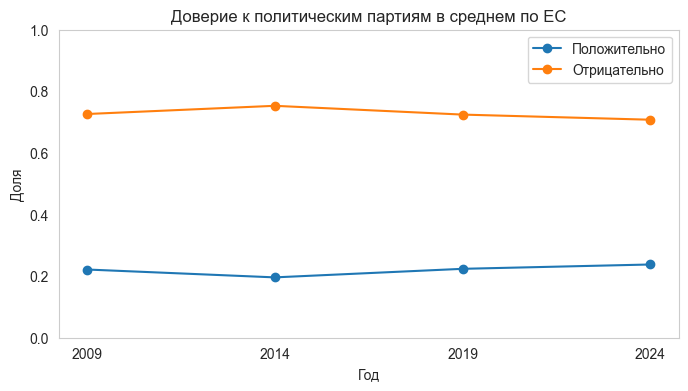

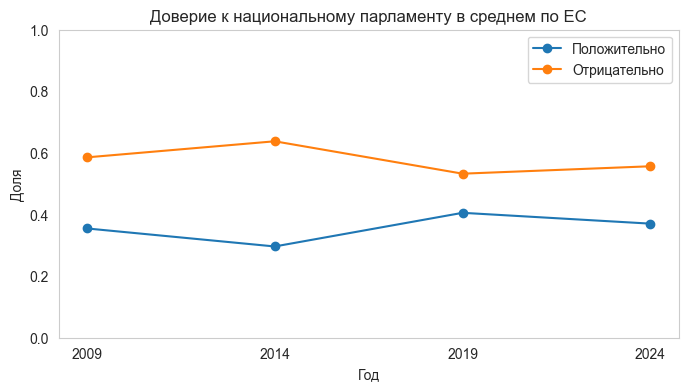

In [23]:
# политика
plot_economy_trend('trust_eu_yes', 'trust_eu_no', 'Доверие к институтам ЕС в среднем по ЕС')
plot_economy_trend('trust_parties_yes', 'trust_parties_no', 'Доверие к политическим партиям в среднем по ЕС')
plot_economy_trend('trust_parliment_yes', 'trust_parliment_no', 'Доверие к национальному парламенту в среднем по ЕС')

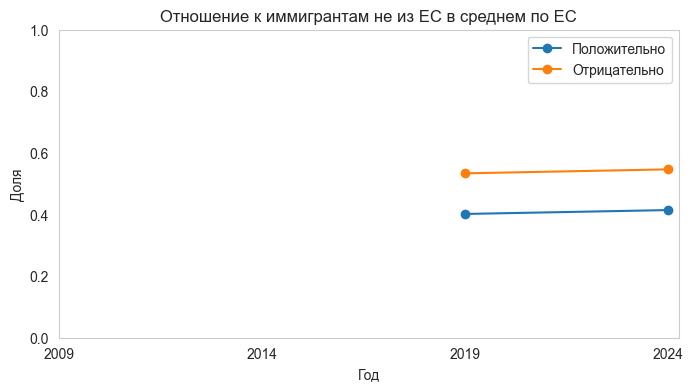

In [24]:
# это плохие данные, так как только 2 опроса для нас подходят, но пусть визуализация будет
# иммиграция
plot_economy_trend('immigration_out_eu_yes', 'immigration_out_eu_no', 'Отношение к иммигрантам не из ЕС в среднем по ЕС')


# <font color='red'>3.Спецификации моделей. Тестирование эмпирических гипотез</font>

## <font color='blue'>Подготовка</font>

In [25]:
df['date'] = pd.to_datetime(df['date'])

# Подготовка данных
eu_elections = df[df['type_election'] == 'EU']
national_elections = df[df['type_election'] == 'National']

In [26]:
eu_elections = eu_elections.sort_values(['country', 'date'])

national_elections = national_elections.sort_values(['country', 'date'])

In [27]:
national_elections_grouped = national_elections.groupby(['country', 'date', 'ideology'])['result'].sum().reset_index().sort_values(['country', 'date'])
eu_elections_grouped = eu_elections.groupby(['country', 'date', 'ideology'])['result'].sum().reset_index().sort_values(['country', 'date'])

In [28]:
# ## Add previous EU elections date
# data_prev = eu_elections_grouped[['country', 'date']].drop_duplicates()
# data_prev['eu_date_prev'] = data_prev.groupby(['country'])['date'].shift()
# eu_elections_grouped = eu_elections_grouped.join(data_prev.set_index(['country', 'date']), on=['country', 'date'])
# eu_elections_grouped['eu_date_prev'].fillna(pd.Timestamp('2000-01-01T12'), inplace=True)
# eu_elections_grouped

In [29]:
# Добавление колонки нац выборов до ЕС

aggregated_df = eu_elections_grouped.join(
    national_elections_grouped.set_index(['country', 'ideology']), on=['country', 'ideology'],
    rsuffix='_national_before'
).query('date >= date_national_before' 
# & date_national_before >= eu_date_prev'
).groupby(['country', 'ideology', 'date']).last().reset_index()

aggregated_df = aggregated_df.rename({"result": "eu_result", "date": "eu_date"}, axis=1)

In [30]:
# Добавление колонки нац выборов после ЕС

aggregated_df = aggregated_df.sort_values(['country', 'eu_date'])
aggregated_df = aggregated_df.join(
    national_elections_grouped.set_index(['country', 'ideology']), on=['country', 'ideology'],
    rsuffix='_national_after'
).rename({"date": "date_national_after", "result": "result_national_after"}, axis=1)
aggregated_df.loc[aggregated_df['date_national_after']<=aggregated_df['eu_date'],['date_national_after', 'result_national_after']] = np.nan
# .query('eu_date < date_national_after or date_national_after.isna()' 
# # & date_national_before >= eu_date_prev'
aggregated_df = aggregated_df.groupby(['country', 'ideology', 'eu_date']).first().reset_index()

Добавление необходимых статистик

In [31]:
df_w_stats = aggregated_df.join(eu_elections[['country', 'date', 'turnout']].drop_duplicates().rename({'date': 'eu_date'}, axis=1).set_index(['country', 'eu_date']), 
                   on=['country', 'eu_date'], how='left'
                   ).rename({'turnout': 'eu_turnout'}, axis=1)

In [32]:
df_w_stats = df_w_stats.join(national_elections[['country', 'date', 'turnout']].drop_duplicates().rename({'date': 'date_national_before'}, axis=1).set_index(['country', 'date_national_before']), 
                   on=['country', 'date_national_before'], how='left'
                   ).rename({'turnout': 'national_before_turnout'}, axis=1)

In [33]:
ruling_party_groupped = national_elections.groupby(['country', 'date', 'ideology'])['ruling_party'].unique()

In [34]:
df_w_stats = df_w_stats.join(ruling_party_groupped.reset_index().rename({'date': 'date_national_before'}, axis=1).set_index(['country', 'ideology', 'date_national_before']), 
                   on=['country', 'ideology', 'date_national_before'], how='left'
                   ).rename({'ruling_party': 'ruling_party_before'}, axis=1)

In [35]:
df_w_stats['ruling_party_before_dummy'] = df_w_stats['ruling_party_before'].apply(lambda x: 1 in x or 2 in x).astype(int)

In [36]:
# df_w_stats['ruling_party_before_dummy'] = df_w_stats['ruling_party_before'].apply(lambda x: 1 in x)*1

In [37]:
df_w_stats.head(1)

,country,ideology,eu_date,eu_result,date_national_before,result_national_before,date_national_after,result_national_after,eu_turnout,national_before_turnout,ruling_party_before,ruling_party_before_dummy
0,Austria,Christian democracy,2009-06-04,29.98,2008-09-28,26.0,2013-09-29,23.99,45.97,78.8,[2.0],1


In [38]:
df_eb.head(1)

,year,country,national_economy_good,national_economy_bad,european_economy_good,european_economy_bad,household_good,household_bad,trust_eu_yes,trust_eu_no,trust_parties_yes,trust_parties_no,trust_parliment_yes,trust_parliment_no,immigration_out_eu_yes,immigration_out_eu_no,name
0,2009,BE,0.22,0.77,0.26,0.72,0.79,0.2,0.59,0.37,0.28,0.7,0.41,0.56,NaN,NaN,Belgium


In [39]:
df_w_stats['year'] = df_w_stats.eu_date.dt.year
df_w_stats = df_w_stats.merge(df_eb, how='left', left_on=['country', 'year'], right_on = ['name', 'year'])
df_w_stats.head()

,country_x,ideology,eu_date,eu_result,date_national_before,result_national_before,date_national_after,result_national_after,eu_turnout,national_before_turnout,...,household_bad,trust_eu_yes,trust_eu_no,trust_parties_yes,trust_parties_no,trust_parliment_yes,trust_parliment_no,immigration_out_eu_yes,immigration_out_eu_no,name
0,Austria,Christian democracy,2009-06-04,29.98,2008-09-28,26.00,2013-09-29,23.99,45.97,78.8,...,0.28,0.44,0.49,0.40,0.53,0.58,0.36,NaN,NaN,Austria
1,Austria,Christian democracy,2014-05-25,26.98,2013-09-29,23.99,2017-10-15,31.47,45.39,74.9,...,0.22,0.31,0.61,0.23,0.72,0.35,0.55,NaN,NaN,Austria
2,Austria,Christian democracy,2019-05-26,34.55,2017-10-15,31.47,2019-09-29,37.46,59.77,80.0,...,0.13,0.52,0.42,0.33,0.63,0.50,0.42,0.46,0.46,Austria
3,Austria,Christian democracy,2024-06-09,24.52,2019-09-29,37.46,2024-09-29,26.27,56.25,75.6,...,0.20,0.46,0.46,0.35,0.59,0.54,0.40,0.41,0.52,Austria
4,Austria,Far-right,2009-06-04,12.71,2008-09-28,28.20,2013-09-29,20.51,45.97,78.8,...,0.28,0.44,0.49,0.40,0.53,0.58,0.36,NaN,NaN,Austria


In [40]:
df_w_stats = df_w_stats.rename(columns = {'country_x':'country'}).drop(columns = ['country_y', 'year', 'name'])


In [41]:
df_w_stats.head(5)

,country,ideology,eu_date,eu_result,date_national_before,result_national_before,date_national_after,result_national_after,eu_turnout,national_before_turnout,...,household_good,household_bad,trust_eu_yes,trust_eu_no,trust_parties_yes,trust_parties_no,trust_parliment_yes,trust_parliment_no,immigration_out_eu_yes,immigration_out_eu_no
0,Austria,Christian democracy,2009-06-04,29.98,2008-09-28,26.00,2013-09-29,23.99,45.97,78.8,...,0.71,0.28,0.44,0.49,0.40,0.53,0.58,0.36,NaN,NaN
1,Austria,Christian democracy,2014-05-25,26.98,2013-09-29,23.99,2017-10-15,31.47,45.39,74.9,...,0.76,0.22,0.31,0.61,0.23,0.72,0.35,0.55,NaN,NaN
2,Austria,Christian democracy,2019-05-26,34.55,2017-10-15,31.47,2019-09-29,37.46,59.77,80.0,...,0.83,0.13,0.52,0.42,0.33,0.63,0.50,0.42,0.46,0.46
3,Austria,Christian democracy,2024-06-09,24.52,2019-09-29,37.46,2024-09-29,26.27,56.25,75.6,...,0.74,0.20,0.46,0.46,0.35,0.59,0.54,0.40,0.41,0.52
4,Austria,Far-right,2009-06-04,12.71,2008-09-28,28.20,2013-09-29,20.51,45.97,78.8,...,0.71,0.28,0.44,0.49,0.40,0.53,0.58,0.36,NaN,NaN


In [42]:
df_w_stats["diff_eu_nat_before"] = df_w_stats.eu_result - df_w_stats.result_national_before
column_to_move = df_w_stats.pop('diff_eu_nat_before')
df_w_stats.insert(6,"diff_eu_nat_before",column_to_move)

In [43]:
df_w_stats["diff_eu_nat_after"] = df_w_stats.eu_result - df_w_stats.result_national_after
column_to_move = df_w_stats.pop('diff_eu_nat_after')
df_w_stats.insert(9,"diff_eu_nat_after",column_to_move)


In [44]:
df_w_stats["diff_eu_nat_before_module"] = np.abs(df_w_stats.eu_result - df_w_stats.result_national_before)
column_to_move = df_w_stats.pop('diff_eu_nat_before_module')
df_w_stats.insert(7,"diff_eu_nat_before_module",column_to_move)


In [45]:
df_w_stats["diff_eu_nat_after_module"] = np.abs(df_w_stats.eu_result - df_w_stats.result_national_after)
column_to_move = df_w_stats.pop('diff_eu_nat_after_module')
df_w_stats.insert(10,"diff_eu_nat_after_module",column_to_move)

In [46]:
fin_df = df_w_stats

## <font color='blue'>Формирование финального датасета. Описательные статистики</font>

In [47]:
# Преобразуем даты в формат datetime
fin_df['date_national_before'] = pd.to_datetime(fin_df['date_national_before'])
fin_df['date_national_after'] = pd.to_datetime(fin_df['date_national_after'])
fin_df['eu_date'] = pd.to_datetime(fin_df['eu_date'])
fin_df

,country,ideology,eu_date,eu_result,date_national_before,result_national_before,diff_eu_nat_before,diff_eu_nat_before_module,date_national_after,result_national_after,...,household_good,household_bad,trust_eu_yes,trust_eu_no,trust_parties_yes,trust_parties_no,trust_parliment_yes,trust_parliment_no,immigration_out_eu_yes,immigration_out_eu_no
0,Austria,Christian democracy,2009-06-04,29.98,2008-09-28,26.00,3.98,3.98,2013-09-29,23.99,...,0.71,0.28,0.44,0.49,0.40,0.53,0.58,0.36,NaN,NaN
1,Austria,Christian democracy,2014-05-25,26.98,2013-09-29,23.99,2.99,2.99,2017-10-15,31.47,...,0.76,0.22,0.31,0.61,0.23,0.72,0.35,0.55,NaN,NaN
2,Austria,Christian democracy,2019-05-26,34.55,2017-10-15,31.47,3.08,3.08,2019-09-29,37.46,...,0.83,0.13,0.52,0.42,0.33,0.63,0.50,0.42,0.46,0.46
3,Austria,Christian democracy,2024-06-09,24.52,2019-09-29,37.46,-12.94,12.94,2024-09-29,26.27,...,0.74,0.20,0.46,0.46,0.35,0.59,0.54,0.40,0.41,0.52
4,Austria,Far-right,2009-06-04,12.71,2008-09-28,28.20,-15.49,15.49,2013-09-29,20.51,...,0.71,0.28,0.44,0.49,0.40,0.53,0.58,0.36,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
511,Sweden,Liberalism,2024-06-09,11.67,2022-09-22,11.32,0.35,0.35,NaT,NaN,...,0.90,0.10,0.63,0.28,0.38,0.58,0.68,0.28,0.67,0.32
512,Sweden,Social democracy,2009-06-07,24.41,2006-10-17,34.99,-10.58,10.58,2010-09-19,30.66,...,0.88,0.11,0.46,0.45,0.36,0.59,0.64,0.32,NaN,NaN
513,Sweden,Social democracy,2014-05-25,24.19,2010-09-19,30.66,-6.47,6.47,2014-09-14,31.01,...,0.90,0.10,0.37,0.49,0.39,0.56,0.67,0.27,NaN,NaN
514,Sweden,Social democracy,2019-05-26,23.48,2018-09-09,28.26,-4.78,4.78,2022-09-22,30.33,...,0.89,0.11,0.56,0.37,0.38,0.59,0.58,0.40,0.61,0.36


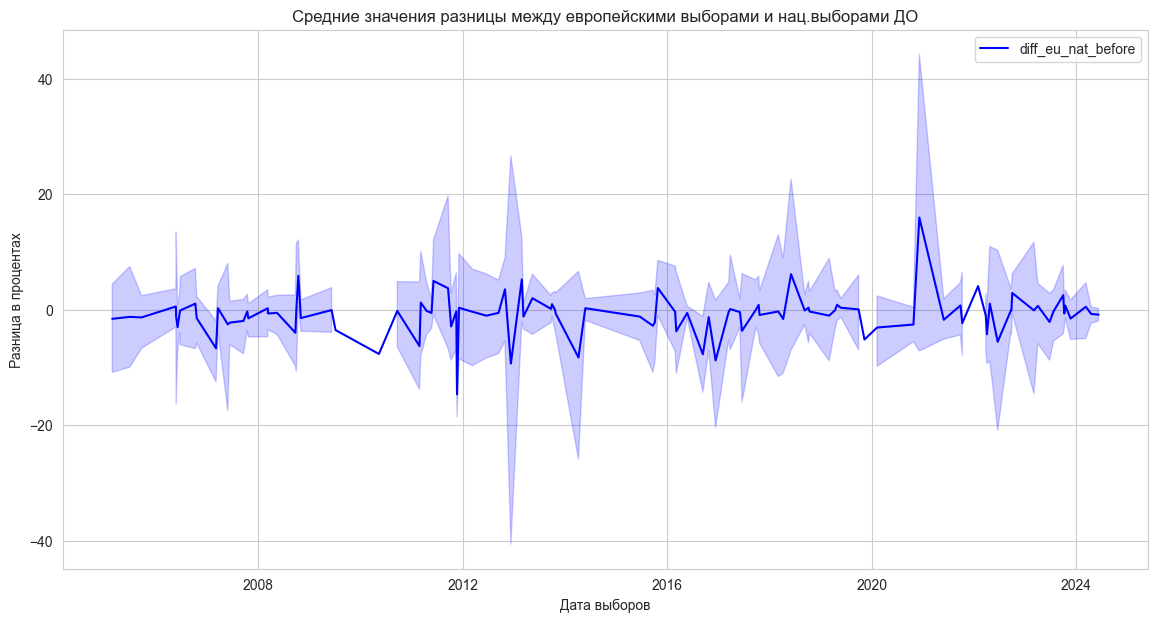

In [48]:
# Общий график со средними значениями для всех стран и партий
plt.figure(figsize=(14, 7))
sns.lineplot(x='date_national_before', y='diff_eu_nat_before', data=fin_df, label='diff_eu_nat_before', color='blue', estimator='mean')
plt.title('Средние значения разницы между европейскими выборами и нац.выборами ДО')
plt.xlabel('Дата выборов')
plt.ylabel('Разница в процентах')
plt.legend()
plt.savefig('Средние значения разницы между европейскими выборами и нац.выборами ДО.png')  # Сохранение графика в формате PNG
plt.show()

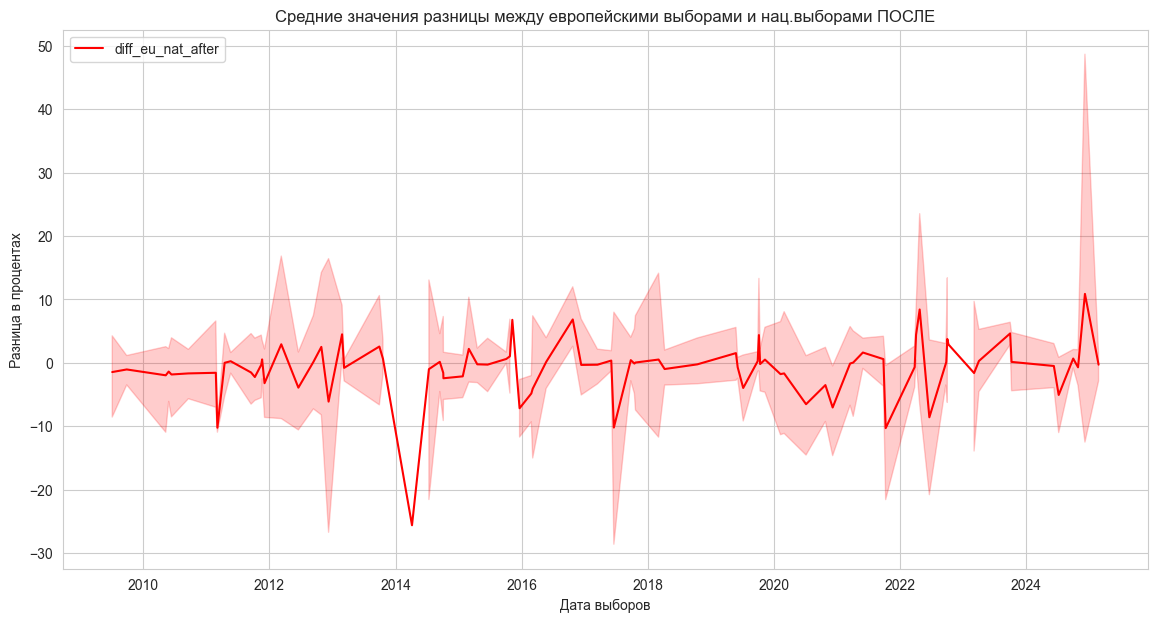

In [49]:
plt.figure(figsize=(14, 7))
sns.lineplot(x='date_national_after', y='diff_eu_nat_after', data=fin_df, label='diff_eu_nat_after', color='red', estimator='mean')
plt.title('Средние значения разницы между европейскими выборами и нац.выборами ПОСЛЕ')
plt.xlabel('Дата выборов')
plt.ylabel('Разница в процентах')
plt.legend()
plt.show()

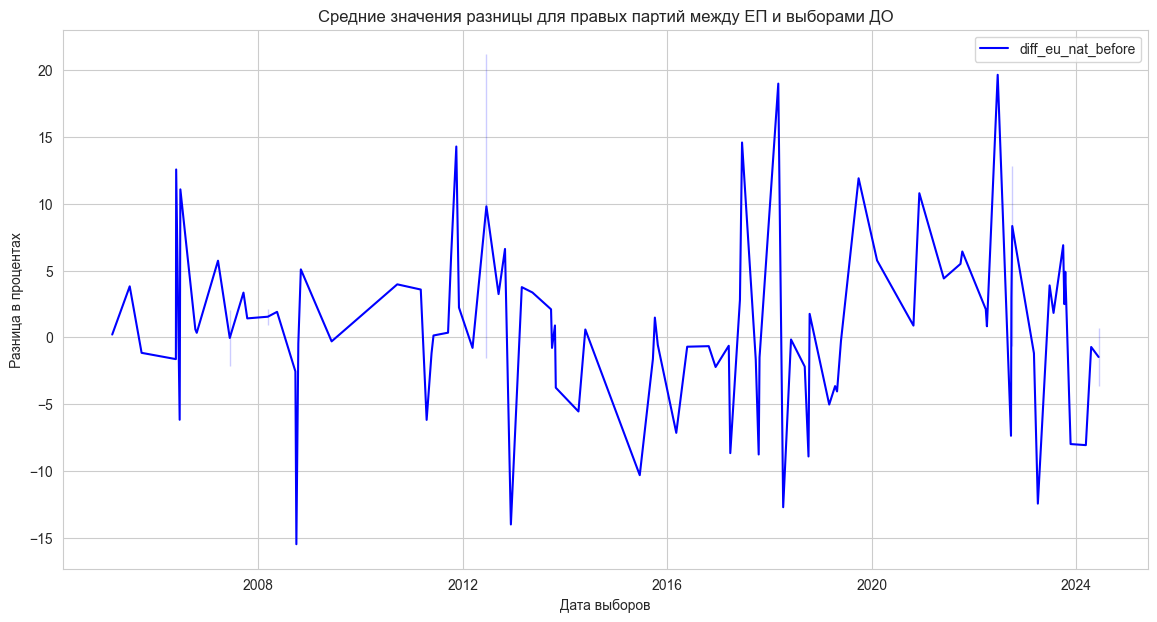

In [50]:
# Графики для правых партий
far_right_data = fin_df[fin_df['ideology'] == 'Far-right']

# График для Far-right (до)
plt.figure(figsize=(14, 7))
sns.lineplot(x='date_national_before', y='diff_eu_nat_before', data=far_right_data, label='diff_eu_nat_before', color='blue', estimator='mean')
plt.title('Средние значения разницы для правых партий между ЕП и выборами ДО')
plt.xlabel('Дата выборов')
plt.ylabel('Разница в процентах')
plt.legend()
plt.savefig('Средние значения разницы для правых партий.png')
plt.show()

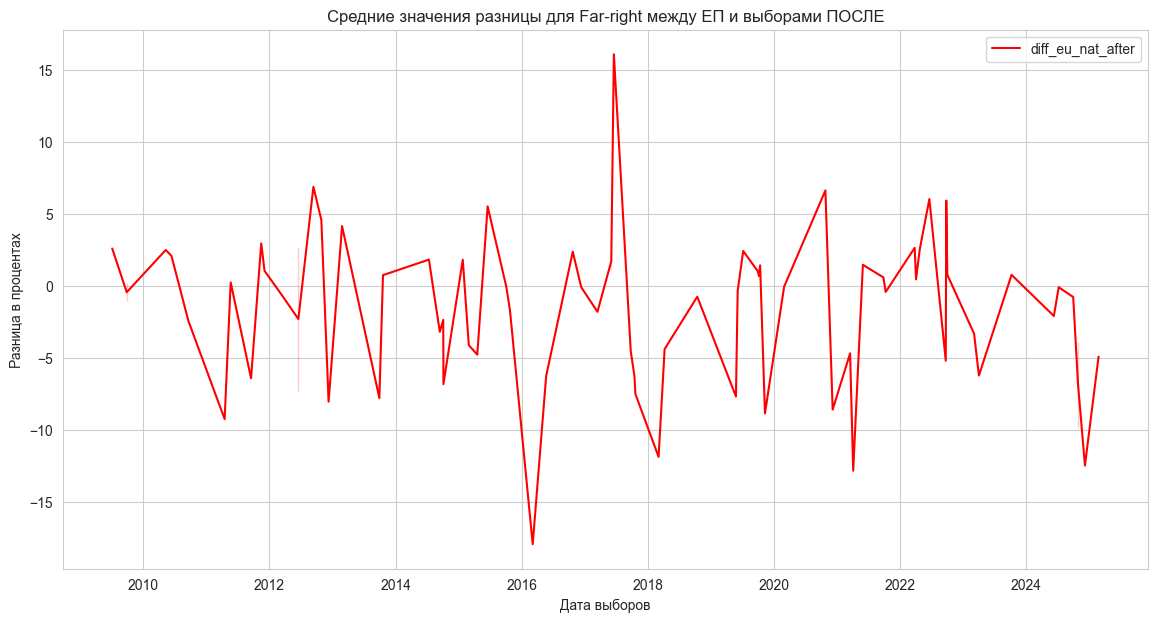

In [51]:
# График для Far-right (после)
plt.figure(figsize=(14, 7))
sns.lineplot(x='date_national_after', y='diff_eu_nat_after', data=far_right_data, label='diff_eu_nat_after', color='red', estimator='mean')
plt.title('Средние значения разницы для Far-right между ЕП и выборами ПОСЛЕ')
plt.xlabel('Дата выборов')
plt.ylabel('Разница в процентах')
plt.legend()
plt.show()

In [52]:
# Средние значения разницы для каждой страны 
country_means = fin_df.groupby('country')[['diff_eu_nat_before', 'diff_eu_nat_after']].mean().sort_values(by='diff_eu_nat_before', ascending=False)
print("Средние значения разницы выступления партий по странам:")
print(country_means)
# отсортировано по убыванию разницы выборов в ЕП с нац выборами ДО

dfi.export(
    country_means,
    'Средние значения разницы выступления партий по странам.png',
    table_conversion='matplotlib',  # Или 'chrome' для стилизации CSS
    fontsize=12,
    max_rows=-1,  # Все строки
    dpi=300       # Высокое разрешение
)

Средние значения разницы выступления партий по странам:
             diff_eu_nat_before  diff_eu_nat_after
country                                           
Latvia                 3.241000           0.218333
Italy                  1.198889           1.928462
Lithuania              0.825263           0.862778
Portugal               0.753158           1.605000
Austria                0.487368           0.762105
Finland                0.150500           0.023333
Poland                 0.112667          -0.301818
Germany               -0.114800          -0.050870
Slovenia              -0.159412           1.218462
Luxembourg            -0.278261           0.153529
Bulgaria              -0.371667          -0.882222
Belgium               -0.429583          -0.093529
Sweden                -0.483214          -0.547143
Denmark               -0.486071          -0.424762
Malta                 -0.515625          -0.234545
Slovakia              -0.526111          -0.141429
Cyprus                -0.5

In [53]:
# Средние разницы для Far-right 
far_right_means = far_right_data.groupby('country')[['diff_eu_nat_before', 'diff_eu_nat_after']].mean().sort_values(by='diff_eu_nat_before', ascending=False)
print("\nСредние значения разницы выступлений правых партий по странам:")
print(far_right_means)
# отсортировано по убыванию разницы выборов в ЕП с нац выборами ДО

dfi.export(
    far_right_means,
    'Средние значения разницы выступлений правых партий по странам.png',
    table_conversion='matplotlib',  # Или 'chrome' для стилизации CSS
    fontsize=12,
    max_rows=-1,  # Все строки
    dpi=300       # Высокое разрешение
)


Средние значения разницы выступлений правых партий по странам:
             diff_eu_nat_before  diff_eu_nat_after
country                                           
France                14.375000           6.185000
Italy                  6.905000          -0.600000
Ireland                5.760000                NaN
Latvia                 3.542000          -2.666667
Poland                 3.476667          -0.115000
Malta                  2.000000           2.026667
Lithuania              1.595000           0.950000
Netherlands            1.425000           0.133333
Luxembourg             1.210000           0.256667
Germany                1.195000          -2.482500
Denmark                1.180000           2.716667
Greece                 1.010000          -1.010000
Czechia                0.386667          -3.970000
Cyprus                 0.222500          -1.516667
Romania               -0.087500          -7.307500
Slovenia              -0.160000           1.800000
Belgium           

In [54]:
country_means_des = country_means.describe()

dfi.export(
    country_means_des,
    'описательные для всех.png',
    table_conversion='matplotlib',  # Или 'chrome' для стилизации CSS
    fontsize=12,
    max_rows=-1,  # Все строки
    dpi=300       # Высокое разрешение
)
country_means_des

,diff_eu_nat_before,diff_eu_nat_after
count,27.000000,27.000000
mean,-0.697537,-0.840699
std,1.472060,2.003420
min,-3.755000,-7.898333
25%,-1.649583,-2.234306
50%,-0.486071,-0.234545
75%,-0.001067,0.185931
max,3.241000,1.928462


In [55]:
far_right_means_des = far_right_means.describe()

dfi.export(
    far_right_means_des,
    'описательные для правых.png',
    table_conversion='matplotlib',  # Или 'chrome' для стилизации CSS
    fontsize=12,
    max_rows=-1,  # Все строки
    dpi=300       # Высокое разрешение
)

far_right_means_des

,diff_eu_nat_before,diff_eu_nat_after
count,27.000000,25.000000
mean,0.979642,-1.848500
std,3.623482,3.479181
min,-4.135000,-8.870000
25%,-1.163750,-3.720000
50%,0.222500,-1.516667
75%,1.510000,0.256667
max,14.375000,6.185000


**Интересно** можем заметить, что для многих стран голосование за правых менее волатильное между выборами в ЕП и национальными, по сравнению с общей разницей. Мы это видим как и по странам, так и по описательным статистикам: для правых медиана и среднее ниже.


In [56]:
far_right_data = fin_df[fin_df['ideology'] == 'Far-right']

## <font color='blue'>Формулировка гипотез</font>

**Исследовательские:** 

**H1(основная):** отношение европейских избирателей к выборам в ЕП изменилось, и стало более серьезным. Следовательно, голосование на выборах второго порядка становится менее радикальным и маргинальным. **Партии правых популистов будут получать сопоставимую поддержку на выборах в ЕП, как и на предшествующих общеевропейским национальных выборах в своих странах**. Другими словами, мы увидим общий восходящий тренд голосования за правые партии на выборах любого порядка.

**Н2:** результаты правых популистских партий будут отличаться по странам: в некоторых странах голосование за правых останется простестным в рамках теории о выборах второго порядка, однако в других странах тренд голосования на разных типах выборов будет один.

**Н3:** хорошее выступление правых популистов на выборах в ЕП будет повышать их электоральную поддержку на следующих выборах в национальные парламенты

**При этом другие характеристики выборов второго порядка будут сохраняться:**

**Н4:** инкумбент будет получать меньшую поддержку на выборах в Европарламент, чем на национальных выборах.

**Н5:** явка на выборах в Европарламент будет ниже, чем на национальных выборах

In [57]:
# Наш основной датасет
fin_df

,country,ideology,eu_date,eu_result,date_national_before,result_national_before,diff_eu_nat_before,diff_eu_nat_before_module,date_national_after,result_national_after,...,household_good,household_bad,trust_eu_yes,trust_eu_no,trust_parties_yes,trust_parties_no,trust_parliment_yes,trust_parliment_no,immigration_out_eu_yes,immigration_out_eu_no
0,Austria,Christian democracy,2009-06-04,29.98,2008-09-28,26.00,3.98,3.98,2013-09-29,23.99,...,0.71,0.28,0.44,0.49,0.40,0.53,0.58,0.36,NaN,NaN
1,Austria,Christian democracy,2014-05-25,26.98,2013-09-29,23.99,2.99,2.99,2017-10-15,31.47,...,0.76,0.22,0.31,0.61,0.23,0.72,0.35,0.55,NaN,NaN
2,Austria,Christian democracy,2019-05-26,34.55,2017-10-15,31.47,3.08,3.08,2019-09-29,37.46,...,0.83,0.13,0.52,0.42,0.33,0.63,0.50,0.42,0.46,0.46
3,Austria,Christian democracy,2024-06-09,24.52,2019-09-29,37.46,-12.94,12.94,2024-09-29,26.27,...,0.74,0.20,0.46,0.46,0.35,0.59,0.54,0.40,0.41,0.52
4,Austria,Far-right,2009-06-04,12.71,2008-09-28,28.20,-15.49,15.49,2013-09-29,20.51,...,0.71,0.28,0.44,0.49,0.40,0.53,0.58,0.36,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
511,Sweden,Liberalism,2024-06-09,11.67,2022-09-22,11.32,0.35,0.35,NaT,NaN,...,0.90,0.10,0.63,0.28,0.38,0.58,0.68,0.28,0.67,0.32
512,Sweden,Social democracy,2009-06-07,24.41,2006-10-17,34.99,-10.58,10.58,2010-09-19,30.66,...,0.88,0.11,0.46,0.45,0.36,0.59,0.64,0.32,NaN,NaN
513,Sweden,Social democracy,2014-05-25,24.19,2010-09-19,30.66,-6.47,6.47,2014-09-14,31.01,...,0.90,0.10,0.37,0.49,0.39,0.56,0.67,0.27,NaN,NaN
514,Sweden,Social democracy,2019-05-26,23.48,2018-09-09,28.26,-4.78,4.78,2022-09-22,30.33,...,0.89,0.11,0.56,0.37,0.38,0.59,0.58,0.40,0.61,0.36


## <font color='blue'>Переменные для моделей</font>

In [58]:
fin_df.columns

Index(['country', 'ideology', 'eu_date', 'eu_result', 'date_national_before',
       'result_national_before', 'diff_eu_nat_before',
       'diff_eu_nat_before_module', 'date_national_after',
       'result_national_after', 'diff_eu_nat_after_module',
       'diff_eu_nat_after', 'eu_turnout', 'national_before_turnout',
       'ruling_party_before', 'ruling_party_before_dummy',
       'national_economy_good', 'national_economy_bad',
       'european_economy_good', 'european_economy_bad', 'household_good',
       'household_bad', 'trust_eu_yes', 'trust_eu_no', 'trust_parties_yes',
       'trust_parties_no', 'trust_parliment_yes', 'trust_parliment_no',
       'immigration_out_eu_yes', 'immigration_out_eu_no'],
      dtype='object')

**Зависимые (для разных спецификаций):**  eu_result, diff_eu_nat_before, eu_turnout

**Предикторы:** ideology, result_national_before, ruling_party_before_dummy,  national_economy_bad, european_economy_bad, household_bad, trust_eu_no, trust_parties_no, trust_parliment_no

## <font color='blue'>Проверка на мультиколлинеарность</font>

In [59]:
selected_df = fin_df[['result_national_before', 'ruling_party_before_dummy', 'national_economy_bad', 'european_economy_bad',
                      'household_bad','trust_eu_no','trust_parties_no', 'trust_parliment_no', 'eu_turnout']]
corr_matrix = selected_df.corr(numeric_only = True)
corr_matrix

,result_national_before,ruling_party_before_dummy,national_economy_bad,european_economy_bad,household_bad,trust_eu_no,trust_parties_no,trust_parliment_no,eu_turnout
result_national_before,1.000000,0.407636,0.118233,0.026406,0.144323,-0.007685,0.078853,0.101967,-0.072339
ruling_party_before_dummy,0.407636,1.000000,0.025745,0.011331,-0.033938,0.026392,0.016788,0.018892,-0.007151
national_economy_bad,0.118233,0.025745,1.000000,0.489866,0.805487,0.272992,0.740124,0.764096,-0.418216
european_economy_bad,0.026406,0.011331,0.489866,1.000000,0.238683,0.495108,0.138370,0.123865,0.053654
household_bad,0.144323,-0.033938,0.805487,0.238683,1.000000,0.192505,0.729653,0.785068,-0.406536
trust_eu_no,-0.007685,0.026392,0.272992,0.495108,0.192505,1.000000,0.362806,0.339390,-0.036718
trust_parties_no,0.078853,0.016788,0.740124,0.138370,0.729653,0.362806,1.000000,0.904681,-0.424728
trust_parliment_no,0.101967,0.018892,0.764096,0.123865,0.785068,0.339390,0.904681,1.000000,-0.467057
eu_turnout,-0.072339,-0.007151,-0.418216,0.053654,-0.406536,-0.036718,-0.424728,-0.467057,1.000000


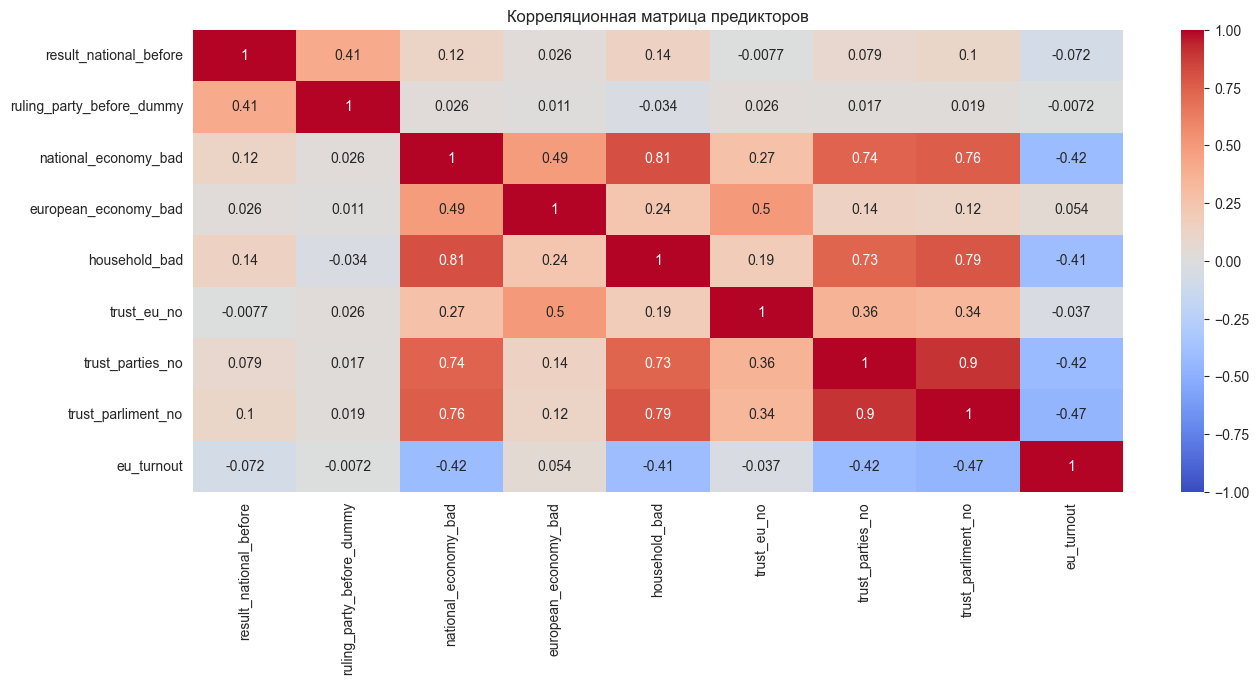

In [60]:
plt.figure(figsize=(15, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Корреляционная матрица предикторов')
plt.show()

In [61]:
vif_data = pd.DataFrame()
vif_data['feature'] = selected_df.columns
vif_data['VIF'] = [variance_inflation_factor(selected_df.values, i) 
                   for i in range(selected_df.shape[1])]

print(vif_data)

                     feature        VIF
0     result_national_before   3.721563
1  ruling_party_before_dummy   2.079541
2       national_economy_bad  30.553365
3       european_economy_bad  17.120012
4              household_bad  15.519024
5                trust_eu_no  23.643530
6           trust_parties_no  85.296292
7         trust_parliment_no  73.066257
8                 eu_turnout   9.396992


**Важно:** мы видим высокий VIF у социологических данных, поэтому нам надо избатьвиться от мультиколлинеарности с помощью МГК.

In [62]:
# Выбираем только проблемные столбцы
X = selected_df[['national_economy_bad', 'european_economy_bad',
                      'household_bad','trust_eu_no','trust_parties_no', 'trust_parliment_no']]
# Стандартизация данных 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Создаем объект PCA
pca = PCA(n_components=None, whiten=True)
X_pca = pca.fit_transform(X_scaled)

In [63]:
# Просмотр объясненной дисперсии
explained_variance = pca.explained_variance_ratio_


threshold = 0.95
cumulative_variance = 0
n_components = 0

for variance in explained_variance:
    cumulative_variance += variance
    n_components += 1
    if cumulative_variance >= threshold:
        break


In [64]:
# Доли дисперсии для первых 4 компонент
print("Доли дисперсии:", explained_variance[:4])

# Накопленная дисперсия
print("Накопленная дисперсия:", np.cumsum(explained_variance)[:4])

Доли дисперсии: [0.60644154 0.21027311 0.1136228  0.03710456]
Накопленная дисперсия: [0.60644154 0.81671465 0.93033745 0.96744201]


**Важно:** исходим из способности интерпретировать содержание компонент, а также их объяснительной силы. Мы выбираем 2 ГК: объясняют 80% варианции, а также возможно объяснение. 1ГК: trust_parliment_no, national_economy_bad, trust_parties_no, household_bad индекс "негативного восприятия институтов и экономики страны". 2ГК: european_economy_bad и european_economy_bad, это "Скептицизм по отношению к ЕС"

In [65]:
# Создаем объект PCA с выбранным количеством компонент
pca = PCA(n_components=2, whiten=True)
X_pca = pca.fit_transform(X_scaled)

n_components = 2
# Получаем веса ТОЛЬКО для выбранных компонент
loadings = pca.components_[:n_components, :]  # Берем первые n_components строк

# Создаем DataFrame для наглядности
loadings_df = pd.DataFrame(
    loadings,
    columns=X.columns,  # Исходные признаки
    index=[f'PC_{i+1}' for i in range(n_components)]  # Главные компоненты
)
loadings_df

,national_economy_bad,european_economy_bad,household_bad,trust_eu_no,trust_parties_no,trust_parliment_no
PC_1,0.477490,0.224184,0.456757,0.250998,0.470489,0.478287
PC_2,0.004267,0.710279,-0.210177,0.591208,-0.209772,-0.240373


In [66]:
# Создаем новые столбцы в датафрейме
pca_df = pd.DataFrame(X_pca[:, :n_components], index=selected_df.index, 
                     columns=[f'PCA_{i+1}' for i in range(n_components)])

# Объединение с исходным датафреймом
selected_df = pd.concat([selected_df, pca_df], axis=1)

# Удаляем исходные коллинеарные столбцы
selected_df = selected_df.drop(columns=['national_economy_bad', 'european_economy_bad',
                      'household_bad','trust_eu_no','trust_parties_no', 'trust_parliment_no'])

In [67]:
selected_df = selected_df.rename(columns = {'PCA_1': 'national_level_trust', 'PCA_2': 'eu_level_trust'})
selected_df

,result_national_before,ruling_party_before_dummy,eu_turnout,national_level_trust,eu_level_trust
0,26.00,1,45.97,-0.235741,1.838823
1,23.99,1,45.39,0.138847,1.508202
2,31.47,1,59.77,-1.022377,-0.201143
3,37.46,1,56.25,-0.646222,0.617515
4,28.20,0,45.97,-0.235741,1.838823
...,...,...,...,...,...
511,11.32,1,53.39,-1.308156,-0.377070
512,34.99,0,45.53,-0.531777,1.593785
513,30.66,0,51.07,-1.020557,2.113813
514,28.26,1,55.27,-1.144786,-0.011896


In [68]:
vif_data = pd.DataFrame()
vif_data['feature'] = selected_df.columns
vif_data['VIF'] = [variance_inflation_factor(selected_df.values, i) 
                   for i in range(selected_df.shape[1])]

print(vif_data)

                     feature       VIF
0     result_national_before  3.300889
1  ruling_party_before_dummy  2.024486
2                 eu_turnout  2.693335
3       national_level_trust  1.105126
4             eu_level_trust  1.036685


In [69]:
selected_df.head()

,result_national_before,ruling_party_before_dummy,eu_turnout,national_level_trust,eu_level_trust
0,26.00,1,45.97,-0.235741,1.838823
1,23.99,1,45.39,0.138847,1.508202
2,31.47,1,59.77,-1.022377,-0.201143
3,37.46,1,56.25,-0.646222,0.617515
4,28.20,0,45.97,-0.235741,1.838823


In [70]:
selected_df_PCA = selected_df[['national_level_trust','eu_level_trust']]
selected_df_PCA.head()

,national_level_trust,eu_level_trust
0,-0.235741,1.838823
1,0.138847,1.508202
2,-1.022377,-0.201143
3,-0.646222,0.617515
4,-0.235741,1.838823


In [71]:
fin_df = pd.concat([fin_df,selected_df_PCA], axis=1)


In [72]:
fin_df.head()

,country,ideology,eu_date,eu_result,date_national_before,result_national_before,diff_eu_nat_before,diff_eu_nat_before_module,date_national_after,result_national_after,...,trust_eu_yes,trust_eu_no,trust_parties_yes,trust_parties_no,trust_parliment_yes,trust_parliment_no,immigration_out_eu_yes,immigration_out_eu_no,national_level_trust,eu_level_trust
0,Austria,Christian democracy,2009-06-04,29.98,2008-09-28,26.00,3.98,3.98,2013-09-29,23.99,...,0.44,0.49,0.40,0.53,0.58,0.36,NaN,NaN,-0.235741,1.838823
1,Austria,Christian democracy,2014-05-25,26.98,2013-09-29,23.99,2.99,2.99,2017-10-15,31.47,...,0.31,0.61,0.23,0.72,0.35,0.55,NaN,NaN,0.138847,1.508202
2,Austria,Christian democracy,2019-05-26,34.55,2017-10-15,31.47,3.08,3.08,2019-09-29,37.46,...,0.52,0.42,0.33,0.63,0.50,0.42,0.46,0.46,-1.022377,-0.201143
3,Austria,Christian democracy,2024-06-09,24.52,2019-09-29,37.46,-12.94,12.94,2024-09-29,26.27,...,0.46,0.46,0.35,0.59,0.54,0.40,0.41,0.52,-0.646222,0.617515
4,Austria,Far-right,2009-06-04,12.71,2008-09-28,28.20,-15.49,15.49,2013-09-29,20.51,...,0.44,0.49,0.40,0.53,0.58,0.36,NaN,NaN,-0.235741,1.838823


## <font color='blue'>Визуализация трендов для правых</font>

In [73]:
far_right_data['eu_date'] = far_right_data['eu_date'].dt.year


C:\Users\Acer\AppData\Local\Temp\ipykernel_18480\1973320693.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  far_right_data['eu_date'] = far_right_data['eu_date'].dt.year


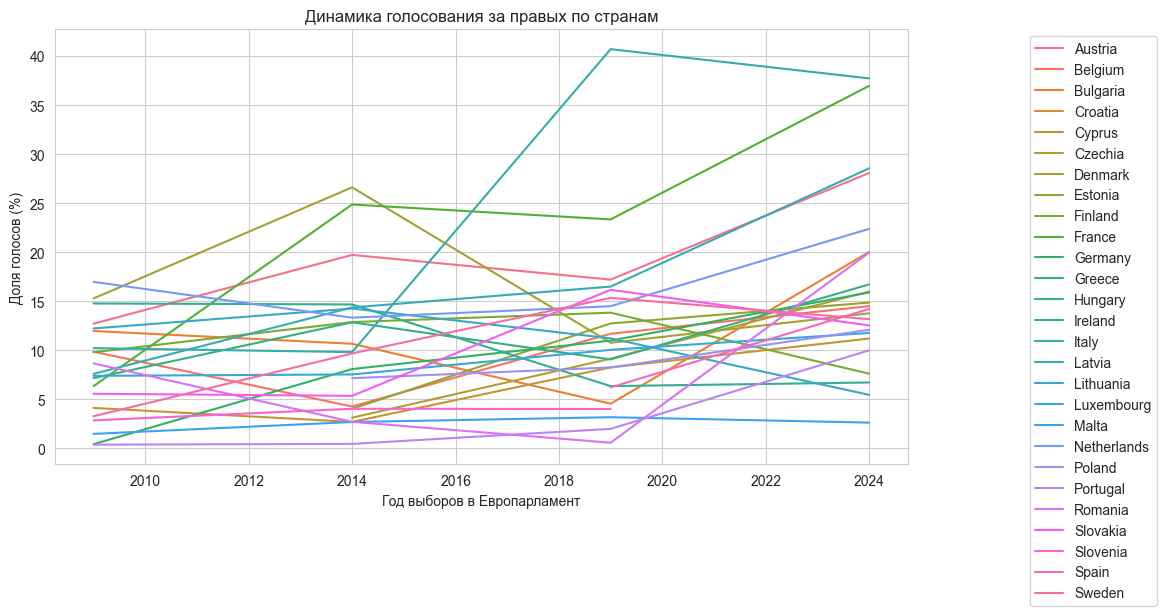

In [74]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=far_right_data, x='eu_date', y='eu_result', hue='country')

# Переименование осей 
plt.xlabel("Год выборов в Европарламент")  
plt.ylabel("Доля голосов (%)")            

# Настройка легенды
plt.legend(
    loc='upper right',          # Позиция: верхний правый угол
    bbox_to_anchor=(1.3, 1)    # Сдвиг легенды вправо за пределы графика
)

plt.title("Динамика голосования за правых по странам")
plt.tight_layout()  # Автоматическая подгонка отступов
plt.savefig('динамика_по_странам.png')  # Сохранение графика в формате PNG
plt.show()



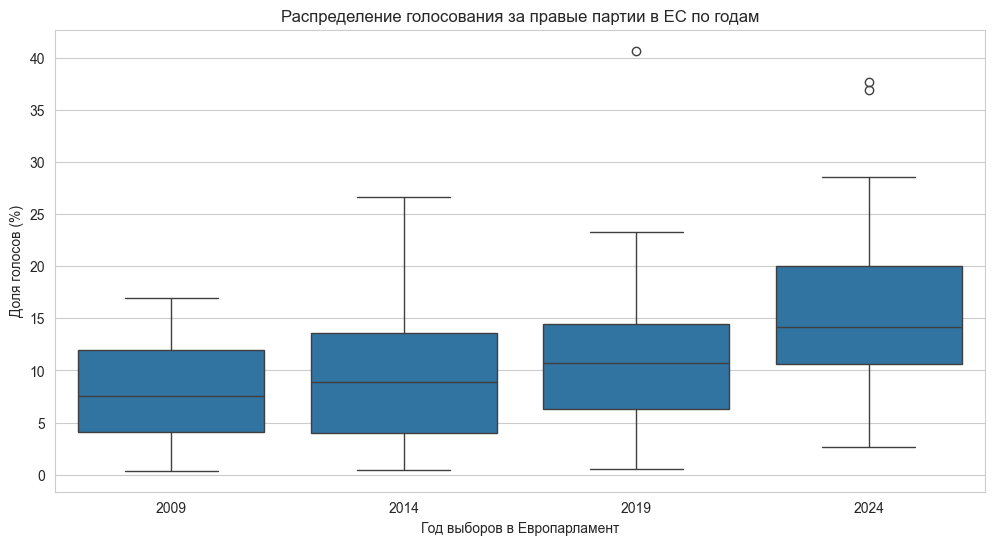

In [75]:
# График по годам
plt.figure(figsize=(12, 6))
sns.boxplot(data=far_right_data, x='eu_date', y='eu_result')
# Переименование осей (добавьте эти строки)
plt.xlabel("Год выборов в Европарламент")  # Название оси X
plt.ylabel("Доля голосов (%)")             # Название оси Y
plt.title("Распределение голосования за правые партии в ЕС по годам")
plt.savefig('Распределение по годам.png')  # Сохранение графика в формате PNG
plt.show()

**Важно:** 

На первом графике видим видимые различия средних значений зависимой переменной по странам, подтверждение, что подходит FE модель.
На втором графике мы общий тренд на рост зависимой переменной во времени, поэтому мы должны построить модель и с TimeEffects. Это также подходит под наши исследвоательские задачи и вопросы о различиях в уровне поддержки между странами.

In [76]:
# far_right_data.date_national_before = far_right_data.date_national_before.dt.year

In [77]:
far_right_data.groupby('eu_date').result_national_before.mean()

eu_date
2009     7.130000
2014     8.125833
2019    13.131600
2024    13.362963
Name: result_national_before, dtype: float64

In [78]:
far_right_data.groupby('eu_date').result_national_after.mean()

eu_date
2009     8.572857
2014    12.411667
2019    12.228000
2024    26.388333
Name: result_national_after, dtype: float64

In [79]:
far_right_data.groupby('date_national_before').result_national_before.mean()

date_national_before
2005-02-20     0.16
2005-06-25     8.14
2005-09-18     1.58
2006-05-21     5.75
2006-05-23     2.20
              ...  
2023-10-15     7.17
2023-11-22    30.37
2024-03-10    18.06
2024-04-17     9.56
2024-06-09    18.73
Name: result_national_before, Length: 91, dtype: float64

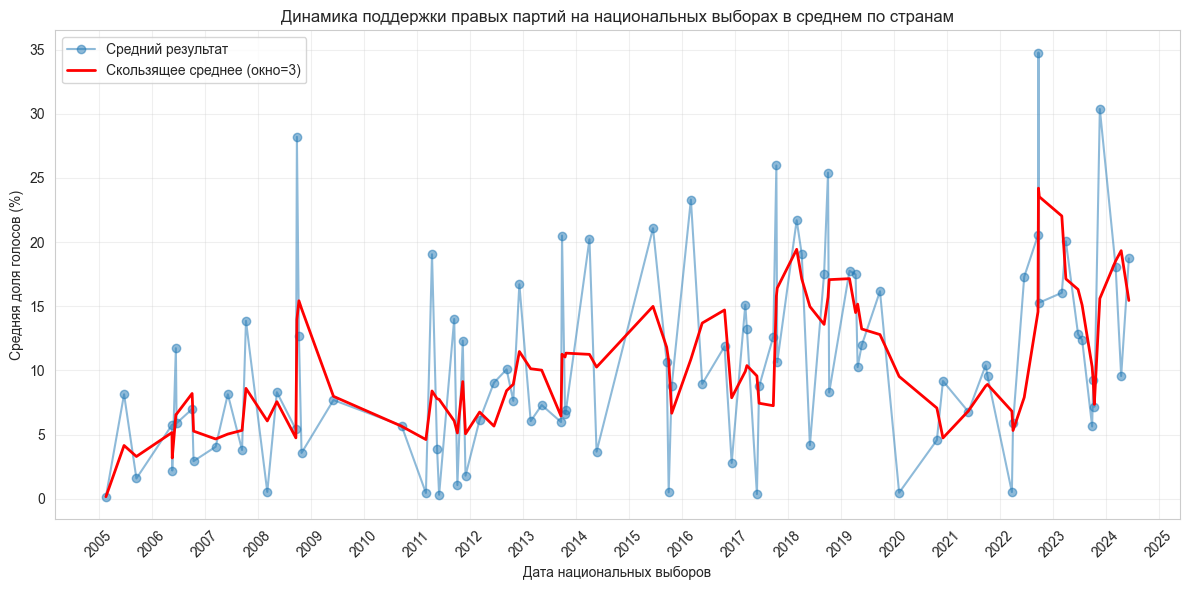

In [80]:
# 1. Создаем временной ряд
ts = far_right_data.groupby('date_national_before').result_national_before.mean()

# 2. Сортируем по дате (важно для скользящего среднего)
ts = ts.sort_index()

# 3. Вычисляем скользящее среднее с окном в 3 периода
window_size = 3  # Можно настроить под ваши данные
rolling_mean = ts.rolling(window=window_size, min_periods=1).mean()

# 4. Создаем график
plt.figure(figsize=(12, 6))

# Исходные данные
plt.plot(ts.index, ts.values, 
         'o-', 
         alpha=0.5, 
         label='Средний результат')

# Скользящее среднее
plt.plot(rolling_mean.index, 
         rolling_mean.values, 
         'r-', 
         linewidth=2, 
         label=f'Скользящее среднее (окно={window_size})')

# 5. Настройка оформления
plt.title('Динамика поддержки правых партий на национальных выборах в среднем по странам')
plt.xlabel('Дата национальных выборов')
plt.ylabel('Средняя доля голосов (%)')
plt.grid(alpha=0.3)
plt.legend()

# Форматирование дат
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.xticks(rotation=45)

# 6. Сохранение и отображение
plt.tight_layout()
plt.savefig('тренды_нацвыборы_даты.png', dpi=300)
plt.show()


In [81]:
far_right_data.date_national_before = far_right_data.date_national_before.dt.year

C:\Users\Acer\AppData\Local\Temp\ipykernel_18480\2912546139.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  far_right_data.date_national_before = far_right_data.date_national_before.dt.year


C:\Users\Acer\AppData\Local\Temp\ipykernel_18480\3599238219.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  far_right_data['above_4pct'] = far_right_data['result_national_before'] > 4


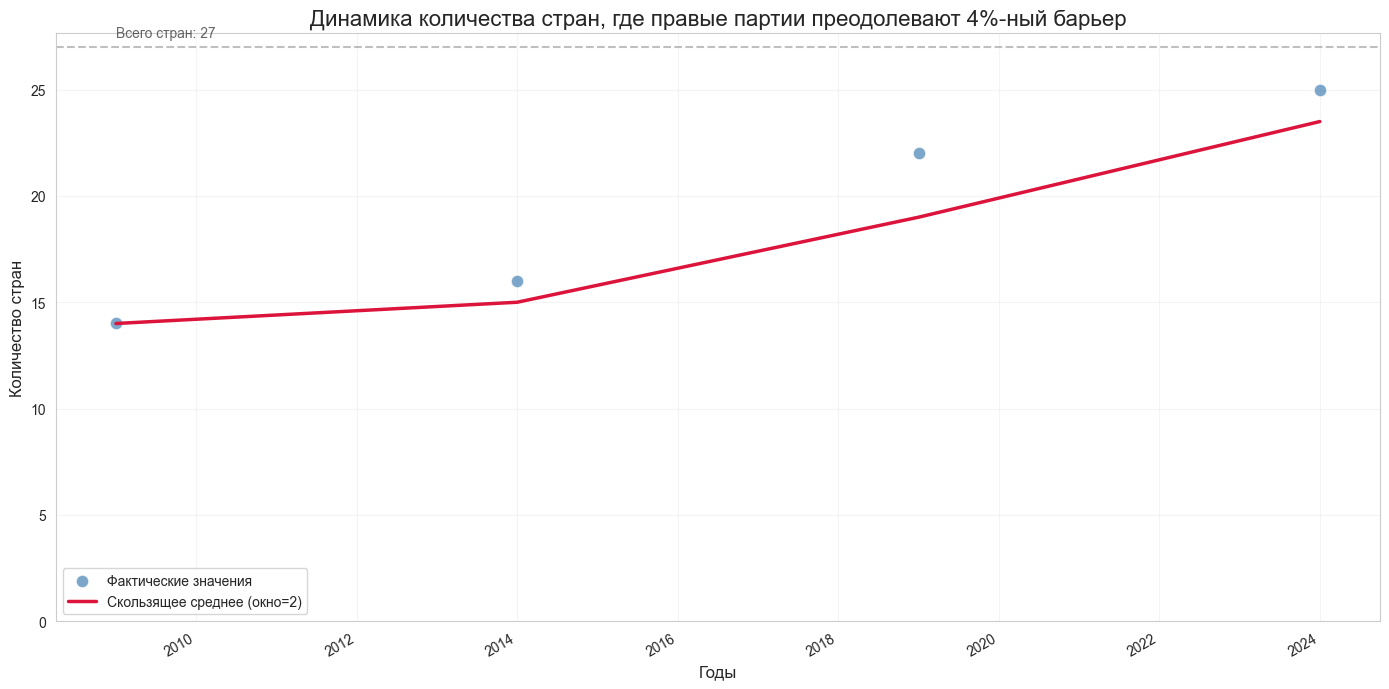

In [82]:
# 1. Создаем столбец с флагом преодоления 4%-ного барьера
far_right_data['above_4pct'] = far_right_data['result_national_before'] > 4

# 2. Группируем по дате выборов и считаем количество стран
trend_data = (
    far_right_data
    .groupby('eu_date')
    .agg(
        num_countries_above_4=('above_4pct', 'sum'),  # Количество стран с >4%
        total_countries=('country', 'nunique')        # Общее количество стран с выборами
    )
    .reset_index()
    .sort_values('eu_date')
)

# 3. Рассчитываем скользящее среднее
window_size = 2  # Размер окна для сглаживания
trend_data['ma_num_countries'] = (
    trend_data['num_countries_above_4']
    .rolling(window=window_size, min_periods=1)
    .mean()
)

# 4. Строим график
plt.figure(figsize=(14, 7))

# Исходные данные (точечный график)
sns.scatterplot(
    data=trend_data,
    x='eu_date',
    y='num_countries_above_4',
    s=80,
    color='steelblue',
    alpha=0.7,
    label='Фактические значения'
)

# Линия скользящего среднего
sns.lineplot(
    data=trend_data,
    x='eu_date',
    y='ma_num_countries',
    color='crimson',
    linewidth=2.5,
    label=f'Скользящее среднее (окно={window_size})'
)

# 5. Настройка оформления
plt.title('Динамика количества стран, где правые партии преодолевают 4%-ный барьер', fontsize=16)
plt.xlabel('Годы', fontsize=12)
plt.ylabel('Количество стран', fontsize=12)
plt.grid(alpha=0.2)
plt.legend()

# 6. Показываем ОБЩЕЕ количество стран для контекста
total_countries = far_right_data['country'].nunique()  # Фиксируем общее число стран

plt.axhline(y=total_countries, color='grey', linestyle='--', alpha=0.5)
plt.text(
    x=trend_data['eu_date'].min(),
    y=total_countries + 0.5,
    s=f'Всего стран: {total_countries}',
    alpha=0.7
)

# 7. Оптимизация отображения дат
plt.gcf().autofmt_xdate()  # Автоповорот дат для читаемости
plt.gca().set_ylim(bottom=0)  # устанавливаем нижнюю границу Y в 0


# 8. Сохранение и отображение
plt.tight_layout()
plt.savefig('правые 4 процента.png', dpi=300)
plt.show()

In [83]:
result = (
    far_right_data.sort_values('date_national_before')
    .groupby('country')
    .last()[['date_national_before', 'result_national_before']]
)
result = result.sort_values('result_national_before', ascending = False)

dfi.export(
    result,
    'правые по странам стата.png',
    table_conversion='matplotlib',  # Или 'chrome' для стилизации CSS
    fontsize=12,
    max_rows=-1,  # Все строки
    dpi=300       # Высокое разрешение
)
result

,date_national_before,result_national_before
country,,
Italy,2022,34.77
Netherlands,2023,30.37
Bulgaria,2024,23.69
Sweden,2022,20.54
Finland,2023,20.06
Portugal,2024,18.06
France,2022,17.30
Austria,2019,16.17
Estonia,2023,16.05


## <font color='blue'>Эмпирическая проверка гипотез</font>

In [84]:
model_df = fin_df
model_df.eu_date = model_df.eu_date.dt.year


#### Объединение категорий идеологий 

In [85]:
print(model_df['ideology'].value_counts())

ideology
Social democracy       105
Far-right               97
Christian democracy     82
Liberalism              78
Conservative            59
Green politics          44
Communism               36
Pirate politics          6
Left                     4
Independent              3
Socialism                2
Name: count, dtype: int64


In [86]:
model_df['ideology'] = model_df['ideology'].astype('category')
# Определяем порог для редких категорий (< 10 наблюдений)
threshold = 10
ideology_counts = model_df['ideology'].value_counts()
rare_categories = ideology_counts[ideology_counts < threshold].index

# Заменяем редкие категории на 'Other'
model_df['ideology'] = model_df['ideology'].cat.add_categories(['Other'])
model_df.loc[model_df['ideology'].isin(rare_categories), 'ideology'] = 'Other'
model_df['ideology'] = model_df['ideology'].cat.remove_unused_categories()

print("Обновленное распределение:")
print(model_df['ideology'].value_counts())

Обновленное распределение:
ideology
Social democracy       105
Far-right               97
Christian democracy     82
Liberalism              78
Conservative            59
Green politics          44
Communism               36
Other                   15
Name: count, dtype: int64


#### **H1(основная):** 
Голосование на выборах второго порядка становится менее радикальным и маргинальным. **Партии правых популистов будут получать сопоставимую поддержку на выборах в ЕП, как и на предшествующих общеевропейским национальных выборах в своих странах**. Другими словами, мы увидим общий восходящий тренд голосования за правые партии на выборах любого порядка.

In [87]:
model_df['right_dummy'] = model_df['ideology'].isin(['Far-right']).astype(int)
# создаем дамии переменную: правая партия или нет

In [88]:
pooled1 = statf.ols(
    formula='diff_eu_nat_before ~ result_national_before*right_dummy',
    data=model_df
).fit(cov_type="HC3")
print(pooled1.summary())

                            OLS Regression Results                            
Dep. Variable:     diff_eu_nat_before   R-squared:                       0.243
Model:                            OLS   Adj. R-squared:                  0.238
Method:                 Least Squares   F-statistic:                     32.02
Date:                Tue, 10 Jun 2025   Prob (F-statistic):           5.56e-19
Time:                        14:25:16   Log-Likelihood:                -1752.8
No. Observations:                 516   AIC:                             3514.
Df Residuals:                     512   BIC:                             3531.
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Inte

In [89]:
#LSDV model

model1_1 = statf.ols(formula = 'diff_eu_nat_before ~ result_national_before + C(country)*right_dummy', data = model_df).fit(cov_type = "HC3")
print(model1_1.summary())

                            OLS Regression Results                            
Dep. Variable:     diff_eu_nat_before   R-squared:                       0.331
Model:                            OLS   Adj. R-squared:                  0.253
Method:                 Least Squares   F-statistic:                     3.226
Date:                Tue, 10 Jun 2025   Prob (F-statistic):           8.24e-12
Time:                        14:25:16   Log-Likelihood:                -1720.9
No. Observations:                 516   AIC:                             3552.
Df Residuals:                     461   BIC:                             3785.
Df Model:                          54                                         
Covariance Type:                  HC3                                         
                                            coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

In [90]:
# модель FE c  TimeEffects
model_df_index = fin_df.set_index(['country', 'eu_date'])

model1_2 = PanelOLS.from_formula(formula = 'diff_eu_nat_before ~ result_national_before*right_dummy + TimeEffects', data = model_df_index).fit(cov_type='clustered')
print(model1_2)

                          PanelOLS Estimation Summary                           
Dep. Variable:     diff_eu_nat_before   R-squared:                        0.2433
Estimator:                   PanelOLS   R-squared (Between):             -13.013
No. Observations:                 516   R-squared (Within):               0.2511
Date:                Tue, Jun 10 2025   R-squared (Overall):             -0.2247
Time:                        14:25:16   Log-likelihood                   -1752.2
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      54.538
Entities:                          27   P-value                           0.0000
Avg Obs:                       19.111   Distribution:                   F(3,509)
Min Obs:                       9.0000                                           
Max Obs:                       28.000   F-statistic (robust):             32.685
                            

In [91]:
model1_3 = PanelOLS.from_formula(formula = 'diff_eu_nat_before ~ result_national_before*right_dummy + eu_turnout + TimeEffects', data = model_df_index).fit(cov_type='clustered')
print(model1_3)

                          PanelOLS Estimation Summary                           
Dep. Variable:     diff_eu_nat_before   R-squared:                        0.2440
Estimator:                   PanelOLS   R-squared (Between):             -16.019
No. Observations:                 516   R-squared (Within):               0.2511
Date:                Tue, Jun 10 2025   R-squared (Overall):             -0.3370
Time:                        14:25:17   Log-likelihood                   -1751.9
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      40.988
Entities:                          27   P-value                           0.0000
Avg Obs:                       19.111   Distribution:                   F(4,508)
Min Obs:                       9.0000                                           
Max Obs:                       28.000   F-statistic (robust):             24.462
                            

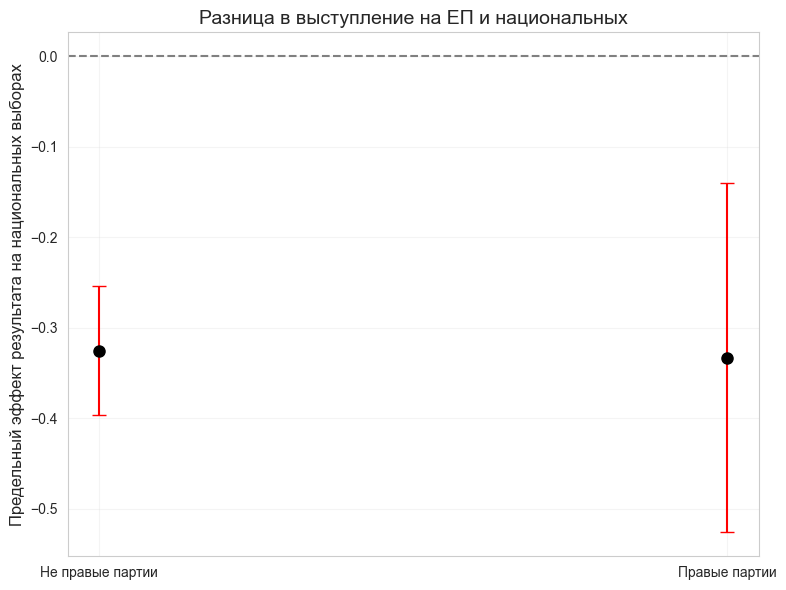

In [92]:
# Извлечение коэффициентов и ковариационной матрицы
coef = model1_3.params
cov = model1_3.cov
# Определение компонентов для взаимодействия
main_effect = "result_national_before"
interaction = "result_national_before:right_dummy"

# Расчет эффектов для right_dummy=0 и right_dummy=1
effect_0 = coef[main_effect]
effect_1 = coef[main_effect] + coef[interaction]

# Расчет стандартных ошибок
se_0 = np.sqrt(cov.loc[main_effect, main_effect])
se_1 = np.sqrt(
    cov.loc[main_effect, main_effect] +
    cov.loc[interaction, interaction] +
    2 * cov.loc[main_effect, interaction]
)

# Построение графика
fig, ax = plt.subplots(figsize=(8, 6))
groups = ["Не правые партии", "Правые партии"]
ax.errorbar(
    groups, [effect_0, effect_1], 
    yerr=[1.96*se_0, 1.96*se_1],
    fmt='o', color='black', 
    ecolor='red', capsize=5, markersize=8
)
ax.axhline(0, color='grey', linestyle='--')
ax.set_ylabel("Предельный эффект результата на национальных выборах", fontsize=12)
ax.set_title("Разница в выступление на ЕП и национальных", fontsize=14)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig("interaction_effect.png", dpi=300)
plt.show()

In [93]:
model1_4 = PanelOLS.from_formula(formula = 'diff_eu_nat_before ~ result_national_before*right_dummy + eu_turnout + national_level_trust + eu_level_trust + TimeEffects', data = model_df_index).fit(cov_type='clustered')
print(model1_4)

                          PanelOLS Estimation Summary                           
Dep. Variable:     diff_eu_nat_before   R-squared:                        0.2481
Estimator:                   PanelOLS   R-squared (Between):             -13.513
No. Observations:                 516   R-squared (Within):               0.2471
Date:                Tue, Jun 10 2025   R-squared (Overall):             -0.2541
Time:                        14:25:17   Log-likelihood                   -1750.5
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      27.822
Entities:                          27   P-value                           0.0000
Avg Obs:                       19.111   Distribution:                   F(6,506)
Min Obs:                       9.0000                                           
Max Obs:                       28.000   F-statistic (robust):             17.778
                            

In [94]:
model1_5 = PanelOLS.from_formula(formula = 'diff_eu_nat_before ~ result_national_before*right_dummy + eu_turnout + ruling_party_before_dummy*right_dummy + TimeEffects', data = model_df_index).fit(cov_type='clustered')
print(model1_5)

                          PanelOLS Estimation Summary                           
Dep. Variable:     diff_eu_nat_before   R-squared:                        0.2471
Estimator:                   PanelOLS   R-squared (Between):             -16.170
No. Observations:                 516   R-squared (Within):               0.2517
Date:                Tue, Jun 10 2025   R-squared (Overall):             -0.3438
Time:                        14:25:17   Log-likelihood                   -1750.8
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      27.683
Entities:                          27   P-value                           0.0000
Avg Obs:                       19.111   Distribution:                   F(6,506)
Min Obs:                       9.0000                                           
Max Obs:                       28.000   F-statistic (robust):             17.321
                            

In [95]:
stargazer = Stargazer([model1_2, model1_3, model1_4, model1_5])

# Настраиваем отображение
stargazer.title("Разница поддержки на выборах в ЕП и национальных выборах.")
stargazer.show_degrees_of_freedom(True)  # Скрыть степени свободы
stargazer.significant_digits(3)          # Количество знаков после запятой

# Переименовываем переменные для читаемости
covariate_map = {
    'result_national_before': 'Результат нац. выборов',
    'right_dummy': 'Правая партия',
    'result_national_before:right_dummy': 'Результат нац. выборов × Правая партия',
    'eu_turnout': 'Явка на выборах в ЕП',
    'Intercept': 'Константа',
    'eu_level_trust': 'Недоверие к ЕС',
    'national_level_trust': 'Недоверие к нац.политике',
    'ruling_party_before_dummy': 'Правящая партия',
    'ruling_party_before_dummy:right_dummy': 'Правящая партия х Правая партия'
}
stargazer.rename_covariates(covariate_map)

stargazer.show_confidence_intervals(True)  # Показывать стандартные ошибки вместо ДИ

# Добавление кастомных строк
stargazer.add_line("Фиксированные эффекты", ["Времени"] * 4)
stargazer.add_line("Кластеризация SE", ["По странам"] * 4)

# # Для просмотра в Jupyter Notebook
# from IPython.display import HTML
# HTML(stargazer.render_html())

html_content = stargazer.render_html()
with open("Н1.html", "w", encoding="utf-8") as f:
    f.write(html_content)

#### **Н2:**

результаты правых популистских партий будут отличаться по странам: в некоторых странах голосование за правых останется простестным в рамках теории о выборах второго порядка, однако в других странах тренд голосования на разных типах выборов будет один.

In [96]:
#LSDV model

model2 = statf.ols(formula = 'diff_eu_nat_before ~ result_national_before + C(country)*right_dummy', data = model_df).fit(cov_type = "HC3")
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:     diff_eu_nat_before   R-squared:                       0.331
Model:                            OLS   Adj. R-squared:                  0.253
Method:                 Least Squares   F-statistic:                     3.226
Date:                Tue, 10 Jun 2025   Prob (F-statistic):           8.24e-12
Time:                        14:25:17   Log-Likelihood:                -1720.9
No. Observations:                 516   AIC:                             3552.
Df Residuals:                     461   BIC:                             3785.
Df Model:                          54                                         
Covariance Type:                  HC3                                         
                                            coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

#### **H3:**
хорошее выступление правых популистов на выборах в ЕП будет повышать их электоральную поддержку на следующих выборах в национальные парламенты

In [97]:
pooled3 = statf.ols(
    formula='diff_eu_nat_after ~ eu_result*right_dummy',
    data=model_df
).fit(cov_type="HC3")
print(pooled3.summary())

                            OLS Regression Results                            
Dep. Variable:      diff_eu_nat_after   R-squared:                       0.058
Model:                            OLS   Adj. R-squared:                  0.051
Method:                 Least Squares   F-statistic:                     6.063
Date:                Tue, 10 Jun 2025   Prob (F-statistic):           0.000483
Time:                        14:25:17   Log-Likelihood:                -1409.0
No. Observations:                 396   AIC:                             2826.
Df Residuals:                     392   BIC:                             2842.
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                -4.30

In [98]:
# модель FE c  TimeEffects
model_df_index = fin_df.set_index(['country', 'eu_date'])

model3_1 = PanelOLS.from_formula(formula = 'diff_eu_nat_after ~ eu_result*right_dummy + TimeEffects', data = model_df_index).fit(cov_type='clustered')
print(model3_1)

                          PanelOLS Estimation Summary                           
Dep. Variable:      diff_eu_nat_after   R-squared:                        0.0590
Estimator:                   PanelOLS   R-squared (Between):             -4.6804
No. Observations:                 396   R-squared (Within):               0.0667
Date:                Tue, Jun 10 2025   R-squared (Overall):             -0.1822
Time:                        14:25:18   Log-likelihood                   -1407.7
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      8.1234
Entities:                          27   P-value                           0.0000
Avg Obs:                       14.667   Distribution:                   F(3,389)
Min Obs:                       4.0000                                           
Max Obs:                       23.000   F-statistic (robust):             6.6816
                            

C:\Users\Acer\.venv\cw_venv\Lib\site-packages\linearmodels\panel\model.py:1219: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)


In [99]:
stargazer = Stargazer([model3_1])

# Настраиваем отображение
stargazer.title("Разница поддержки на выборах в ЕП и национальных выборах после.")
stargazer.show_degrees_of_freedom(True)  # Скрыть степени свободы
stargazer.significant_digits(3)          # Количество знаков после запятой

# Переименовываем переменные для читаемости
covariate_map = {
    'result_national_before': 'Результат нац. выборов',
    'right_dummy': 'Правая партия',
    'result_national_before:right_dummy': 'Результат нац. выборов × Правая партия',
    'eu_turnout': 'Явка на выборах в ЕП',
    'Intercept': 'Константа',
    'eu_level_trust': 'Недоверие к ЕС',
    'national_level_trust': 'Недоверие к нац.политике',
    'ruling_party_before_dummy': 'Правящая партия',
    'ruling_party_before_dummy:right_dummy': 'Правящая партия х Правая партия',
    'eu_result': 'Результат на выборах в ЕП',
    'eu_result:right_dummy': 'Результат правой партии на выборах в ЕП',
}
stargazer.rename_covariates(covariate_map)

stargazer.show_confidence_intervals(True)  # Показывать стандартные ошибки вместо ДИ

# Добавление кастомных строк
stargazer.add_line("Фиксированные эффекты", ["Времени"] )
stargazer.add_line("Кластеризация SE", ["По странам"] )

# # Для просмотра в Jupyter Notebook
# from IPython.display import HTML
# HTML(stargazer.render_html())

html_content = stargazer.render_html()
with open("Н3.html", "w", encoding="utf-8") as f:
    f.write(html_content)

#### **H4:**

инкумбент будет получать меньшую поддержку на выборах в Европарламент, чем на национальных выборах.

In [100]:
pooled4 = statf.ols(
    formula='diff_eu_nat_before ~ ruling_party_before_dummy*result_national_before',
    data=model_df
).fit(cov_type="HC3")
print(pooled4.summary())

                            OLS Regression Results                            
Dep. Variable:     diff_eu_nat_before   R-squared:                       0.249
Model:                            OLS   Adj. R-squared:                  0.244
Method:                 Least Squares   F-statistic:                     34.68
Date:                Tue, 10 Jun 2025   Prob (F-statistic):           2.04e-20
Time:                        14:25:18   Log-Likelihood:                -1750.9
No. Observations:                 516   AIC:                             3510.
Df Residuals:                     512   BIC:                             3527.
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                                                       coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------

In [101]:
# модель FE c  TimeEffects
model4_1 = PanelOLS.from_formula(formula = 'diff_eu_nat_before ~ ruling_party_before_dummy*result_national_before + TimeEffects', data = model_df_index).fit(cov_type='clustered')
print(model4_1)

                          PanelOLS Estimation Summary                           
Dep. Variable:     diff_eu_nat_before   R-squared:                        0.2488
Estimator:                   PanelOLS   R-squared (Between):             -7.4316
No. Observations:                 516   R-squared (Within):               0.2541
Date:                Tue, Jun 10 2025   R-squared (Overall):             -0.0212
Time:                        14:25:18   Log-likelihood                   -1750.3
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      56.191
Entities:                          27   P-value                           0.0000
Avg Obs:                       19.111   Distribution:                   F(3,509)
Min Obs:                       9.0000                                           
Max Obs:                       28.000   F-statistic (robust):             35.628
                            

In [102]:

model4_2 = PanelOLS.from_formula(formula = 'diff_eu_nat_before ~ ruling_party_before_dummy*result_national_before +eu_turnout + national_level_trust + eu_level_trust + TimeEffects', data = model_df_index).fit(cov_type='clustered')
print(model4_2)

                          PanelOLS Estimation Summary                           
Dep. Variable:     diff_eu_nat_before   R-squared:                        0.2527
Estimator:                   PanelOLS   R-squared (Between):             -7.9278
No. Observations:                 516   R-squared (Within):               0.2506
Date:                Tue, Jun 10 2025   R-squared (Overall):             -0.0471
Time:                        14:25:18   Log-likelihood                   -1748.9
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      28.522
Entities:                          27   P-value                           0.0000
Avg Obs:                       19.111   Distribution:                   F(6,506)
Min Obs:                       9.0000                                           
Max Obs:                       28.000   F-statistic (robust):             19.543
                            

In [103]:
stargazer = Stargazer([model4_1, model4_2])

# Настраиваем отображение
stargazer.title("Разница поддержки правящей партии на выборах в ЕП и национальных выборах.")
stargazer.show_degrees_of_freedom(True)  # Скрыть степени свободы
stargazer.significant_digits(3)          # Количество знаков после запятой

# Переименовываем переменные для читаемости
covariate_map = {
    'result_national_before': 'Результат нац. выборов',
    'right_dummy': 'Правая партия',
    'result_national_before:right_dummy': 'Результат нац. выборов × Правая партия',
    'eu_turnout': 'Явка на выборах в ЕП',
    'Intercept': 'Константа',
    'eu_level_trust': 'Недоверие к ЕС',
    'national_level_trust': 'Недоверие к нац.политике',
    'ruling_party_before_dummy': 'Правящая партия',
    'ruling_party_before_dummy:right_dummy': 'Правящая партия х Правая партия',
    'eu_result': 'Результат на выборах в ЕП',
    'eu_result:right_dummy': 'Результат правой партии на выборах в ЕП',
    'ruling_party_before_dummy:result_national_before' : 'Правящая партия х Результат нац. выборов'
}
stargazer.rename_covariates(covariate_map)

stargazer.show_confidence_intervals(True)  # Показывать стандартные ошибки вместо ДИ

# Добавление кастомных строк
stargazer.add_line("Фиксированные эффекты", ["Времени"] *2)
stargazer.add_line("Кластеризация SE", ["По странам"] *2)

# # Для просмотра в Jupyter Notebook
# from IPython.display import HTML
# HTML(stargazer.render_html())

html_content = stargazer.render_html()
with open("Н4.html", "w", encoding="utf-8") as f:
    f.write(html_content)

#### **H5:**

явка на выборах в Европарламент будет ниже, чем на национальных выборах

In [104]:
# Создаем разницу явок
model_df_index['turnout_diff'] = (
    model_df_index['national_before_turnout'] - model_df_index['eu_turnout']
)

# Модель тестирования средней разницы
model5_1 = PanelOLS.from_formula(
    "turnout_diff ~ 1 + TimeEffects",
    data=model_df_index
).fit(cov_type="clustered")

print(model5_1.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:           turnout_diff   R-squared:                      1.11e-16
Estimator:                   PanelOLS   R-squared (Between):              0.0000
No. Observations:                 516   R-squared (Within):               0.0000
Date:                Tue, Jun 10 2025   R-squared (Overall):              0.0000
Time:                        14:25:18   Log-likelihood                   -2062.3
Cov. Estimator:             Clustered                                           
                                        F-statistic:                          --
Entities:                          27   P-value                               --
Avg Obs:                       19.111   Distribution:                         --
Min Obs:                       9.0000                                           
Max Obs:                       28.000   F-statistic (robust):                 --
                            

In [105]:
stargazer = Stargazer([model5_1])

# Настраиваем отображение
stargazer.title("Разница явки на выборах в ЕП и национальных выборах.")
stargazer.show_degrees_of_freedom(True)  # Скрыть степени свободы
stargazer.significant_digits(3)          # Количество знаков после запятой

# Переименовываем переменные для читаемости
covariate_map = {
    'result_national_before': 'Результат нац. выборов',
    'right_dummy': 'Правая партия',
    'result_national_before:right_dummy': 'Результат нац. выборов × Правая партия',
    'eu_turnout': 'Явка на выборах в ЕП',
    'Intercept': 'Разница явки между национальными и ЕП',
    'eu_level_trust': 'Недоверие к ЕС',
    'national_level_trust': 'Недоверие к нац.политике',
    'ruling_party_before_dummy': 'Правящая партия',
    'ruling_party_before_dummy:right_dummy': 'Правящая партия х Правая партия',
    'eu_result': 'Результат на выборах в ЕП',
    'eu_result:right_dummy': 'Результат правой партии на выборах в ЕП',
}
stargazer.rename_covariates(covariate_map)

stargazer.show_confidence_intervals(True)  # Показывать стандартные ошибки вместо ДИ

# Добавление кастомных строк
stargazer.add_line("Фиксированные эффекты", ["Времени"])
stargazer.add_line("Кластеризация SE", ["По странам"])

# # Для просмотра в Jupyter Notebook
# from IPython.display import HTML
# HTML(stargazer.render_html())

html_content = stargazer.render_html()
with open("Н5.html", "w", encoding="utf-8") as f:
    f.write(html_content)